# Completed reasoning-off probes: notebook 16 exploration

This is a copy of notebook 16 restricted to completed 32-layer sweeps. The original
notebook, live kernel, training weights and activation captures are read-only inputs.
All work here uses CPU only. Results go to a separate analysis directory.

The cohort and the top three layers per target/site are frozen using training CV
before opening held-out activations. Full test curves and transfer matrices are
exploratory diagnostics, never a source of layer selection. There are eight held-out
question schedules (640 rows), so rows are not independent replicates.

`answer_line` includes the emitted answer token. Its probes can reflect the answer
already written and cannot establish a computation before the decision. Early
reliability sites precede the observations, so agreement decoding there should be null.


Run all cells in a **new kernel**. CUDA is hidden before importing torch,
and no model weights are loaded. Re-running reuses the frozen snapshot even if the
original training run advances. This bank holds out schedules only: reliability,
prompt rendering, candidate identity and ordering generalization remain untested.


In [1]:
from __future__ import annotations
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['OPENBLAS_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'


import gc
import hashlib
import json
import logging
import math
import os
import re
import shutil
import sys
import tempfile
from collections import Counter, defaultdict
from datetime import datetime, timezone
from fractions import Fraction
from itertools import combinations
from pathlib import Path

# torchao probes optional native extensions during some Transformers imports. The local
# experiment stack does not need those extensions.
os.environ.setdefault("TORCHAO_FORCE_SKIP_LOADING_SO_FILES", "1")
logging.getLogger("torchao").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from safetensors import SafetensorError, safe_open
from safetensors.torch import load_file, save_file
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import (
    balanced_accuracy_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from transformers import AutoConfig, AutoProcessor

REPO_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from mats_experiments.noisy_channel_bayesian import (
    CaptureSpec,
    ExecutionConfig,
    MetricSpec,
    ModelConfig,
    NoisyChannelBayesianEnvironment,
    QwenRunner,
    RandomSubsetQuestion,
    SGLangMTPConfig,
    SystemPrompt,
    TokenizerBinding,
    TranscriptDataset,
    TranscriptDatasetGenerator,
    XVsYPosteriorProbe,
    answer_patterns,
)

torch.set_num_threads(2)
from scipy.special import expit
from completed_probe_exploration import (
    freeze_snapshot, load_test_cache, evaluate_probes, behavior_audit,
    plot_diagnostics, match_audit, write_interpretation,
)


## Configuration

Every experimental, storage, split, probe, visualization, and patching parameter is in this
cell. Native Qwen thinking remains disabled in every condition: `reasoning=True` means
ordinary visible assistant text before `ANSWER:`, as in notebook 13.

Reasoning-off has a 64-token watchdog. Reasoning-on has a 4,096-token watchdog so visible
reasoning has enough room to reach the required terminal answer. Only selected activation
positions are persisted, so the longer generation cap does not multiply disk usage.


In [2]:
# ------------------------------- factorial -------------------------------
MODEL_ID = "Qwen/Qwen3.5-9B"
MODEL_REVISION = "c202236235762e1c871ad0ccb60c8ee5ba337b9a"
N = 9
K = 3
R_VALUES = (
    0.05, 0.15, 0.25, 0.35, 0.45,
    0.55, 0.65, 0.75, 0.85, 0.95,
)
R_EXACT_VALUES = tuple(str(Fraction(str(value))) for value in R_VALUES)
REASONING_VALUES = (False,)
NUM_QUESTION_SETS = 64
NUM_ANSWER_PATTERNS = 8
CONTROL_POSITIONAL_BIAS = False
ALLOW_SAME = False                 # tie rows stay; SAME is not an output option

X = 2
Y = 7
SUBSET_SIZE = 4
SEED = 20260905
SYSTEM_PROMPT_TEXT = (
    "You are a Bayesian reasoner. Follow the user's game rules exactly. "
    "Use plaintext only. Do not use Markdown, headings, bullets, tables, code blocks, "
    "HTML, or any other formatting."
)

# --------------------------- capture and storage --------------------------
ACTIVATION_STREAM = "resid_post"   # exactly one saved activation stream
ACTIVATION_LAYERS = "all"          # all 32 language layers
ACTIVATION_TOKENS = "row_selected" # semantic prompt sites plus final answer tail
NUM_LAYERS = 32
HIDDEN_SIZE = 4096
ACTIVATION_BYTES_PER_ELEMENT = 2    # BF16
MAX_COMPLETION_TOKENS_BY_REASONING = {False: 64, True: 4096}
ANSWER_TAIL_TOKENS = 16
ACTIVATION_STORAGE_BUDGET_GIB = 160.0
ACTIVATION_BUDGET_SAFETY_FRACTION = 0.90
MIN_FREE_DISK_AFTER_CAPTURE_GIB = 25.0

MODEL_DTYPE = "auto"
DEVICE_MAP = None
LOCAL_FILES_ONLY = True
ENABLE_MTP = False
COMPLETION_BATCH_SIZE = 4
CAPTURE_BATCH_SIZE = 1
SCORE_BATCH_SIZE = 4
CAPTURE_CHECKPOINT_ROWS = 8       # persist a contiguous result prefix every 8 rows

EXPERIMENT_ROOT = (
    REPO_ROOT / "artifacts" / "noisy_channel_bayesian_experiment_2_activation_patching"
)
DATASET_RUN_ID = "qwen35_9b_n9_k3_r10_s64_selected_tokens_v2"
MODE_NAMES = {False: "reasoning_off", True: "reasoning_on"}
RUN_IDS = {
    reasoning: f"{DATASET_RUN_ID}_{MODE_NAMES[reasoning]}"
    for reasoning in REASONING_VALUES
}

# ------------------------------ split policy ------------------------------
TEST_SCHEDULE_COUNT = 8
SPLIT_SEARCH_CANDIDATES = 50_000
PREFER_ALL_TIE_CELLS_IN_TEST = True

# ------------------------------- probe plan -------------------------------
# Each entry is a semantically aligned span; multi-token spans are mean pooled.
PROBE_SITES = (
    "domain_boundary",
    "reliability_rule_boundary",
    "reliability_r_value",
    "reliability_one_minus_r_value",
    "report_1_answer",
    "report_2_answer",
    "report_3_answer",
    "observation_question_boundary",
    "candidate_1_value",
    "candidate_2_value",
    "candidate_question_boundary",
    "assistant_turn_boundary",
    "final_prompt",
    "answer_line",
)
CONTINUOUS_PROBE_TARGETS = (
    "delta_a", "gain", "gain_abs", "z_bayes", "z_heuristic",
)
BINARY_PROBE_TARGETS = ("reliability_sign",)
PROBE_LAYERS = tuple(range(NUM_LAYERS))
RIDGE_ALPHAS = tuple(float(value) for value in np.logspace(-3, 6, 10))
RIDGE_SOLVER = "lsqr"
RIDGE_TOL = 1e-5
RIDGE_MAX_ITER = 10_000
LOGISTIC_C_VALUES = tuple(float(value) for value in np.logspace(-4, 4, 9))
PROBE_CV_FOLDS = 5
PROBE_N_JOBS = 32                 # execution-only parallelism; not fingerprinted
PROBE_TOP_K_LAYERS = 3            # selected using training CV only
MIN_GENERATED_SITE_COVERAGE = 0.95
MIN_PROBE_TRAIN_ROWS = HIDDEN_SIZE + 1
PROBE_RUN_ID = "ridge_logistic_split_reasoning_selected_sites_v2"

# ------------------------- probe visualization plan -----------------------
# Full layer sweeps use grouped validation scores, never in-sample R^2.
PROBE_PLOT_TARGETS = CONTINUOUS_PROBE_TARGETS
PROBE_TRANSFER_TARGETS = ("z_bayes",)
PROBE_TRANSFER_LAYERS = (0, 8, 16, 24, 31)
PROBE_FIGURE_DPI = 160

# ------------------------- whole-residual patching ------------------------
PATCH_SITE = "final_prompt"
PATCH_RELIABILITY_PAIRS = (("1/20", "19/20"), ("1/4", "3/4"))
PATCH_MAX_DIRECTIONS = 64
BRIDGE_LOGIT_TOLERANCE = 0.05
PATCH_RUN_ID = "whole_residual_reliability_interchange_v2"

# -------------------------- explicit execution gates ----------------------
RUN_GPU_CAPTURE = False
LOAD_COMPLETED_CAPTURE = True
ANALYSIS_REASONING_VALUES = (False,)  # reasoning_on remains durably paused for later
RUN_PROBE_TRAINING = False
RUN_LOCKED_TEST_EVALUATION = False
RUN_PROBE_VISUALIZATIONS = True
RUN_PROBE_TRANSFER_ANALYSIS = True
RUN_ACTIVATION_PATCHING = False


In [3]:
MODEL_ROOT = EXPERIMENT_ROOT / 'Qwen_Qwen3.5-9B_4c87a623'
SOURCE_PROBE_ROOT = MODEL_ROOT / 'probes' / PROBE_RUN_ID
ANALYSIS_ROOT = MODEL_ROOT / 'analyses' / 'completed_reasoning_off_20260905'
PROBE_ROOT = ANALYSIS_ROOT / 'probes'
RUN_DIRS = {False: MODEL_ROOT / 'runs' / RUN_IDS[False]}
snapshot = freeze_snapshot(SOURCE_PROBE_ROOT, PROBE_ROOT, ANALYSIS_ROOT, REPO_ROOT)
PROBE_CONFIG_FINGERPRINT = snapshot['probe_config_fingerprint']
PROBE_SITES = tuple(snapshot['sites'])
display(pd.DataFrame(snapshot['inventory']))
display({'completed_sites': list(PROBE_SITES), 'probes': len(snapshot['records']),
         'snapshot_time_utc': snapshot['created_at'], 'device': 'cpu'})


,site,complete,delta_a,gain,gain_abs,z_bayes,z_heuristic,reliability_sign
0,domain_boundary,True,32,32,32,32,32,32
1,reliability_rule_boundary,True,32,32,32,32,32,32
2,reliability_r_value,True,32,32,32,32,32,32
3,reliability_one_minus_r_value,True,32,32,32,32,32,32
4,report_1_answer,True,32,32,32,32,32,32
5,report_2_answer,True,32,32,32,32,32,32
6,report_3_answer,True,32,32,32,32,32,32
7,observation_question_boundary,False,16,16,16,16,16,16
8,candidate_1_value,False,0,0,0,0,0,0
9,candidate_2_value,False,0,0,0,0,0,0


{'completed_sites': ['domain_boundary',
  'reliability_rule_boundary',
  'reliability_r_value',
  'reliability_one_minus_r_value',
  'report_1_answer',
  'report_2_answer',
  'report_3_answer',
  'final_prompt',
  'answer_line'],
 'probes': 1728,
 'snapshot_time_utc': '2026-09-05T02:09:29.780481+00:00',
 'device': 'cpu'}

## Load the existing split and captures

No datasets, splits or training plans are regenerated. The original saved labels and
schedule assignments are retained, and all reasoning-on rows are excluded.


### What the probe labels mean

For one transcript, let $a_1,a_2\in\{0,1,2,3\}$ be the numbers of source reports that
candidate 1 and candidate 2 predict correctly. The notebook derives these labels without
consulting Qwen:

$$\Delta a=a_1-a_2,\qquad g(r)=\log\frac{r}{1-r},\qquad
z_{\mathrm{Bayes}}=\Delta a\,g(r).$$

`gain_abs` is $|g(r)|$, `reliability_sign` is $\mathbb{1}[r>1/2]$, and
`z_heuristic` is $\Delta a|g(r)|$. The last target deliberately removes the Bayesian sign
reversal below $r=1/2$, so comparing it with `z_bayes` asks whether the representation
contains the correct signed computation or merely "more agreement means more evidence."

Each target gets a separate probe. Tie rows have $\Delta a=z_{\mathrm{Bayes}}=
z_{\mathrm{heuristic}}=0$, while their gain and reliability-sign labels remain informative.
This is why retaining all four tie constructions helps disentangle evidence balance from
reliability.


In [4]:
def atomic_write_json(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + '.tmp')
    temporary.write_text(json.dumps(payload, indent=2, allow_nan=False) + '\n')
    os.replace(temporary, path)

def atomic_write_jsonl(path, rows):
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + '.tmp')
    temporary.write_text(''.join(json.dumps(row, allow_nan=False) + '\n' for row in rows))
    os.replace(temporary, path)

def agreement_cell(row):
    return int(row['agreement_c1']), int(row['agreement_c2'])

def row_reliability_exact(row):
    return row['reliabilities_exact'][0]


In [4]:
results = [json.loads(line) for line in (RUN_DIRS[False] / 'results.jsonl').read_text().splitlines() if line.strip()]
assert len(results) == 5120 and all(row['reasoning'] is False for row in results)
assert len({row['row_id'] for row in results}) == len(results)
results_by_reasoning = {False: results}
result_by_id = {row['row_id']: row for row in results}
enriched_rows = results
dataset = results
train_rows = [row for row in results if row['split'] == 'train']
test_rows = [row for row in results if row['split'] == 'test']
test_schedule_set = {int(row['question_set_index']) for row in test_rows}
assert len(train_rows) == 4480 and len(test_rows) == 640
assert len(test_schedule_set) == 8
assert test_schedule_set.isdisjoint({row['question_set_index'] for row in train_rows})
assert all(set(record['train_schedule_ids']).isdisjoint(test_schedule_set) for record in snapshot['records'])
EXPECTED_ROWS = 5120
EXPECTED_ROWS_PER_REASONING = 5120
EXPECTED_TRAIN_ROWS = 4480
EXPECTED_TEST_ROWS = EXPECTED_TEST_ROWS_PER_REASONING = 640
TIE_CELLS = {(a, a) for a in range(4)}
display({'train_rows': len(train_rows), 'test_rows': len(test_rows),
         'test_schedules': sorted(test_schedule_set)})


{'train_rows': 4480,
 'test_rows': 640,
 'test_schedules': [0, 1, 2, 3, 4, 6, 9, 10]}

### Split audit

These are the existing held-out schedules, not a new split selected after seeing performance.


In [6]:
def expanded_cell_table(rows: list[dict[str, object]], split: str) -> pd.DataFrame:
    counts = Counter(agreement_cell(row) for row in rows if row["split"] == split)
    return pd.DataFrame(
        [[counts[(a1, a2)] for a2 in range(K + 1)] for a1 in range(K + 1)],
        index=pd.Index(range(K + 1), name="agreement C1"),
        columns=pd.Index(range(K + 1), name="agreement C2"),
    )


train_cell_table = expanded_cell_table(enriched_rows, "train")
test_cell_table = expanded_cell_table(enriched_rows, "test")
display(Markdown("#### Training rows"))
display(train_cell_table)
display(Markdown("#### Test rows"))
display(test_cell_table)

tie_test_counts = {
    cell: int(test_cell_table.loc[cell[0], cell[1]]) for cell in sorted(TIE_CELLS)
}
globally_available_ties = TIE_CELLS & {
    agreement_cell(row) for row in enriched_rows
}
assert all(tie_test_counts[cell] > 0 for cell in globally_available_ties)
print("Test tie-cell counts:", tie_test_counts)


#### Training rows

agreement C2,0,1,2,3
agreement C1,,,,
0,80,160,230,90
1,160,700,590,230
2,230,590,700,160
3,90,230,160,80


#### Test rows

agreement C2,0,1,2,3
agreement C1,,,,
0,10,30,30,10
1,30,90,90,30
2,30,90,90,30
3,10,30,30,10


Test tie-cell counts: {(0, 0): 10, (1, 1): 90, (2, 2): 90, (3, 3): 10}


## Resource isolation

Only frozen probe weights and saved test activations are read. CUDA is unavailable to
this kernel. Activation matrices are cached in CPU memory and released at kernel shutdown.


In [7]:
assert not torch.cuda.is_available()
print('CPU-only analysis; original training process is untouched.')


CPU-only analysis; original training process is untouched.


## Existing capture inventory

The capture remains read-only. Availability is checked at every selected site while
loading the test matrices below.


In [8]:
display({'capture_run': RUN_IDS[False], 'rows': len(results), 'reasoning': False})


{'capture_run': 'qwen35_9b_n9_k3_r10_s64_selected_tokens_v2_reasoning_off',
 'rows': 5120,
 'reasoning': False}

In [9]:
assert all((RUN_DIRS[False] / row['activation_path']).is_file() for row in test_rows)
print('All 640 test capture files exist.')


All 640 test capture files exist.


## Frozen probes

The existing ridge/logistic fits and their scalers are reused. No fitting occurs.
The snapshot validates complete metadata and weight files for all 32 layers and six
targets at every included site. Other sites remain visible in the inventory as incomplete.


In [10]:
def result_site_positions(row: dict[str, object], site: str) -> list[int] | None:
    if site == "answer_line":
        start = row.get("answer_line_generated_token_start")
        end = row.get("answer_line_generated_token_end")
        completion_start = row.get("teacher_forced_completion_start")
        if start is None or end is None or completion_start is None:
            return None
        positions = list(range(
            int(completion_start) + int(start),
            int(completion_start) + int(end),
        ))
        return positions or None
    if site == "answer_prefix":
        value = row.get("answer_boundary_input_index")
        return [int(value)] if value is not None else None
    prompt_sites = row.get("prompt_token_sites", {})
    value = prompt_sites.get(site) if isinstance(prompt_sites, dict) else None
    if isinstance(value, list) and value:
        return [int(position) for position in value]
    if value is not None:
        return [int(value)]
    return None


def result_site_position(row: dict[str, object], site: str) -> int | None:
    positions = result_site_positions(row, site)
    return positions[-1] if positions else None


def activation_path(row: dict[str, object]) -> Path:
    relative = row.get("activation_path")
    if not isinstance(relative, str):
        raise ValueError(f"Row {row['row_id']} has no activation capture.")
    return RUN_DIRS[bool(row["reasoning"])] / relative


def activation_vector(row: dict[str, object], *, site: str, layer: int) -> np.ndarray:
    positions = result_site_positions(row, site)
    if positions is None:
        raise ValueError(f"Row {row['row_id']} has no {site} position.")
    captured_indices = [int(value) for value in row["activation_token_indices"]]
    captured_lookup = {
        absolute_position: stored_position
        for stored_position, absolute_position in enumerate(captured_indices)
    }
    missing = [position for position in positions if position not in captured_lookup]
    if missing:
        raise ValueError(
            f"Row {row['row_id']} did not capture {site} positions {missing}."
        )
    stored_positions = [captured_lookup[position] for position in positions]
    key = f"answer.{ACTIVATION_STREAM}.layer_{layer}"
    with safe_open(activation_path(row), framework="pt", device="cpu") as handle:
        vectors = handle.get_tensor(key)[stored_positions].float().numpy()
    vector = vectors.mean(axis=0)
    if vector.shape != (HIDDEN_SIZE,):
        raise ValueError(f"Unexpected activation-vector shape {vector.shape}.")
    return vector


def rows_available_at_site(result_rows: TranscriptDataset, site: str) -> list[dict[str, object]]:
    rows = []
    for source in result_rows:
        row = dict(source)
        positions = result_site_positions(row, site)
        if positions is None:
            continue
        captured = {
            int(value) for value in row.get("activation_token_indices", [])
        }
        if not set(positions) <= captured:
            if site == "answer_line":
                continue
            missing = sorted(set(positions) - captured)
            raise ValueError(
                f"Row {row['row_id']} is missing captured {site} positions {missing}."
            )
        rows.append(row)
    # Early causal sites intentionally share literal prompt prefixes across many
    # schedules (for example, domain_boundary precedes all sampled evidence).
    # Leakage is therefore defined by experimental unit, not text equality.
    train_schedule_ids = {
        int(row["question_set_index"])
        for row in rows if row["split"] == "train"
    }
    test_schedule_ids = {
        int(row["question_set_index"])
        for row in rows if row["split"] == "test"
    }
    if not train_schedule_ids.isdisjoint(test_schedule_ids):
        raise ValueError(f"Question-schedule leakage detected at site {site}.")
    train_row_ids = {str(row["row_id"]) for row in rows if row["split"] == "train"}
    test_row_ids = {str(row["row_id"]) for row in rows if row["split"] == "test"}
    if not train_row_ids.isdisjoint(test_row_ids):
        raise ValueError(f"Row leakage detected at site {site}.")
    return rows


def activation_matrix(
    rows: list[dict[str, object]], *, site: str, layer: int
) -> np.ndarray:
    return np.stack([
        activation_vector(row, site=site, layer=layer) for row in rows
    ]).astype(np.float32, copy=False)


def activation_site_cache(
    rows: list[dict[str, object]], *, site: str, layers: tuple[int, ...]
) -> np.ndarray:
    """Load every requested layer for one site, opening each row file once."""
    layers = tuple(int(layer) for layer in layers)
    if not layers or len(set(layers)) != len(layers):
        raise ValueError("Site-cache layers must be nonempty and unique.")
    cache = np.empty(
        (len(layers), len(rows), HIDDEN_SIZE), dtype=np.float32
    )
    try:
        for row_index, row in enumerate(rows):
            positions = result_site_positions(row, site)
            if positions is None:
                raise ValueError(f"Row {row['row_id']} has no {site} position.")
            captured_indices = [
                int(value) for value in row["activation_token_indices"]
            ]
            captured_lookup = {
                absolute_position: stored_position
                for stored_position, absolute_position in enumerate(captured_indices)
            }
            missing = [
                position for position in positions
                if position not in captured_lookup
            ]
            if missing:
                raise ValueError(
                    f"Row {row['row_id']} did not capture {site} positions {missing}."
                )
            stored_positions = [captured_lookup[position] for position in positions]
            with safe_open(activation_path(row), framework="pt", device="cpu") as handle:
                for cache_layer_index, layer in enumerate(layers):
                    key = f"answer.{ACTIVATION_STREAM}.layer_{layer}"
                    vectors = (
                        handle.get_tensor(key)[stored_positions].float().numpy()
                    )
                    vector = vectors.mean(axis=0)
                    if vector.shape != (HIDDEN_SIZE,):
                        raise ValueError(
                            f"Unexpected activation-vector shape {vector.shape}."
                        )
                    cache[cache_layer_index, row_index] = vector
            if (row_index + 1) % 256 == 0 or row_index + 1 == len(rows):
                print(
                    datetime.now(timezone.utc).isoformat(),
                    f"cached {site}: {row_index + 1}/{len(rows)} files",
                )
        return cache
    except BaseException:
        del cache
        gc.collect()
        raise


def target_array(rows: list[dict[str, object]], target: str) -> np.ndarray:
    dtype = np.int64 if target in BINARY_PROBE_TARGETS else np.float64
    return np.asarray([row[target] for row in rows], dtype=dtype)


def probe_paths(
    reasoning: bool, site: str, target: str, layer: int
) -> tuple[Path, Path]:
    root = PROBE_ROOT / MODE_NAMES[reasoning] / site / target
    return (
        root / f"layer_{layer:02d}.safetensors",
        root / f"layer_{layer:02d}.json",
    )


def probe_artifacts_match_configuration(
    reasoning: bool, site: str, target: str, layer: int
) -> bool:
    weights_path, metadata_path = probe_paths(reasoning, site, target, layer)
    if not weights_path.is_file() or not metadata_path.is_file():
        return False
    try:
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        with safe_open(weights_path, framework="pt", device="cpu") as handle:
            tensor_metadata = handle.metadata() or {}
        return (
            metadata.get("probe_config_fingerprint") == PROBE_CONFIG_FINGERPRINT
            and tensor_metadata.get("probe_config_fingerprint")
            == PROBE_CONFIG_FINGERPRINT
        )
    except (OSError, ValueError, json.JSONDecodeError, SafetensorError):
        return False



def read_jsonl_if_present(path):
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()] if path.exists() else []


In [11]:
probe_cv_records = snapshot['records']
expected_probe_count = len(probe_cv_records)
locked_layers = snapshot['locked_layers']
display(pd.DataFrame([
    {'site': site, 'target': target, 'locked_layers': layers}
    for site, targets in locked_layers['reasoning_off'].items()
    for target, layers in targets.items()
]))


,site,target,locked_layers
0,domain_boundary,delta_a,"[0, 1, 2]"
1,domain_boundary,gain,"[0, 1, 2]"
2,domain_boundary,gain_abs,"[0, 1, 2]"
3,domain_boundary,z_bayes,"[0, 1, 2]"
4,domain_boundary,z_heuristic,"[0, 1, 2]"
5,domain_boundary,reliability_sign,"[0, 1, 2]"
6,reliability_rule_boundary,delta_a,"[0, 1, 2]"
7,reliability_rule_boundary,gain,"[3, 8, 1]"
8,reliability_rule_boundary,gain_abs,"[4, 2, 12]"
9,reliability_rule_boundary,z_bayes,"[13, 28, 1]"


### Evaluate frozen probes on the held-out schedules

The primary rows below use the training-CV-selected layers. We also save all 32 test
layers as explicitly exploratory curves, without revising the layer lock. Metrics
are separated by reliability regime and include ties for regression; choice accuracy
excludes exact Bayesian ties.


In [12]:
def load_probe_prediction(
    X: np.ndarray, *, reasoning: bool, site: str, target: str, layer: int
) -> np.ndarray:
    if not probe_artifacts_match_configuration(reasoning, site, target, layer):
        raise ValueError("Probe weights or metadata do not match the locked configuration.")
    weights_path, _ = probe_paths(reasoning, site, target, layer)
    tensors = load_file(weights_path)
    mean = tensors["feature_mean"].numpy()
    scale = tensors["feature_scale"].numpy()
    coef = tensors["coef"].numpy()
    intercept = float(tensors["intercept"].reshape(-1)[0])
    score = ((X - mean) / scale) @ coef + intercept
    if target in BINARY_PROBE_TARGETS:
        score = np.where(
            score >= 0,
            1 / (1 + np.exp(-score)),
            np.exp(score) / (1 + np.exp(score)),
        )
    return np.asarray(score)


def continuous_metrics(
    y: np.ndarray, prediction: np.ndarray
) -> dict[str, float | None]:
    correlation = (
        float(np.corrcoef(y, prediction)[0, 1])
        if np.std(y) > 0 and np.std(prediction) > 0 else None
    )
    calibration_slope, calibration_intercept = (
        np.polyfit(prediction, y, 1) if np.std(prediction) > 0 else (None, None)
    )
    return {
        "r2": float(r2_score(y, prediction)),
        "mae": float(mean_absolute_error(y, prediction)),
        "rmse": float(math.sqrt(mean_squared_error(y, prediction))),
        "pearson": correlation,
        "calibration_slope_y_on_prediction": (
            float(calibration_slope) if calibration_slope is not None else None
        ),
        "calibration_intercept_y_on_prediction": (
            float(calibration_intercept) if calibration_intercept is not None else None
        ),
    }


def binary_metrics(y: np.ndarray, probability: np.ndarray) -> dict[str, float]:
    prediction = (probability >= 0.5).astype(int)
    return {
        "auroc": float(roc_auc_score(y, probability)),
        "balanced_accuracy": float(balanced_accuracy_score(y, prediction)),
        "log_loss": float(log_loss(y, probability, labels=[0, 1])),
    }



test_cache = load_test_cache(test_rows, PROBE_SITES, RUN_DIRS[False], HIDDEN_SIZE)
def activation_matrix(rows, *, site, layer):
    # Transfer/scatter cells reuse the same matrices instead of rereading row files.
    ids, matrix = test_cache[site]
    lookup = {row_id: i for i, row_id in enumerate(ids)}
    indices = [lookup[row['row_id']] for row in rows]
    return matrix[int(layer), indices]

test_metric_rows, all_test_metrics, prediction_frame = evaluate_probes(
    results, snapshot, PROBE_ROOT, ANALYSIS_ROOT, test_cache)
display(pd.DataFrame(test_metric_rows).query("subset == 'all' and lock_rank == 1")[
    ['site', 'target', 'layer', 'best_cv_score', 'r2', 'auroc', 'row_count']])


CPU test cache: 80/640 files, 9 sites × 32 layers


CPU test cache: 160/640 files, 9 sites × 32 layers


CPU test cache: 240/640 files, 9 sites × 32 layers


CPU test cache: 320/640 files, 9 sites × 32 layers


CPU test cache: 400/640 files, 9 sites × 32 layers


...

Evaluated frozen probes on test: report_2_answer


Evaluated frozen probes on test: report_3_answer


Evaluated frozen probes on test: final_prompt


Evaluated frozen probes on test: answer_line


,site,target,layer,best_cv_score,r2,auroc,row_count
0,domain_boundary,delta_a,0,0.000000e+00,0.000000e+00,NaN,640
3,domain_boundary,gain,0,-3.552714e-16,0.000000e+00,NaN,640
6,domain_boundary,gain_abs,0,-2.220446e-16,-4.440892e-16,NaN,640
9,domain_boundary,z_bayes,0,0.000000e+00,0.000000e+00,NaN,640
12,domain_boundary,z_heuristic,0,0.000000e+00,0.000000e+00,NaN,640
15,domain_boundary,reliability_sign,0,5.000000e-01,NaN,0.5,640
54,reliability_rule_boundary,delta_a,0,0.000000e+00,0.000000e+00,NaN,640
60,reliability_rule_boundary,reliability_sign,0,1.000000e+00,NaN,1.0,640
87,reliability_rule_boundary,gain,3,1.000000e+00,1.000000e+00,NaN,640
90,reliability_rule_boundary,gain_abs,4,1.000000e+00,1.000000e+00,NaN,640


## Probe geometry and information-transport visualizations

Write each fitted probe as

$$\hat y_{\ell,p}=w_{\ell,p}^{\mathsf T}h_{\ell,p}+b_{\ell,p},$$

where $\ell$ is the residual-stream layer and $p$ is a configured token site. The full
layer/location maps below use **grouped validation** $R^2$ from held-out training schedules;
they never use in-sample training $R^2$. Each separately locked 640-row mode-specific test
set is shown
only after `RUN_LOCKED_TEST_EVALUATION` has deliberately opened it, and only at the layers
selected before opening the test.

All 14 sites are swept independently in each reasoning mode. Figures and transfer matrices
therefore carry an explicit mode label; no plot pools the two probe datasets.

Ridge stores coefficients in standardized-feature coordinates. For geometric comparisons
in the shared residual-stream basis, the code converts them back to the exact raw-space
direction $w_{\rm raw}=w_{\rm standardized}/\sigma$. Cross-layer and cross-location tests
apply the complete source affine readout—including its source mean, scale, and intercept—to
the destination activations. Re-standardizing at the destination would test a different
readout and would not establish transport of the same code.

The generated `answer_line` site may be availability-limited if a completion does not obey
the answer contract. Training aborts if fewer than the configured coverage threshold—or
fewer than 4,097 rows—remain. Test coverage is always written beside its metrics.


In [13]:
FIGURE_ROOT = PROBE_ROOT / "figures"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)


def figure_slug(value: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", value).strip("_")


def save_and_display_figure(fig, name: str) -> Path:
    path = FIGURE_ROOT / f"{figure_slug(name)}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=PROBE_FIGURE_DPI, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return path


def probe_affine_parameters(
    *, reasoning: bool, site: str, target: str, layer: int
) -> dict[str, np.ndarray | float]:
    if not probe_artifacts_match_configuration(reasoning, site, target, layer):
        raise ValueError(
            f"Missing or incompatible probe: "
            f"{MODE_NAMES[reasoning]}/{site}/{target}/layer_{layer:02d}"
        )
    weights_path, _ = probe_paths(reasoning, site, target, layer)
    tensors = load_file(weights_path)
    mean = tensors["feature_mean"].numpy().astype(np.float64, copy=False)
    scale = tensors["feature_scale"].numpy().astype(np.float64, copy=False)
    standardized_coef = tensors["coef"].numpy().astype(np.float64, copy=False)
    intercept = float(tensors["intercept"].reshape(-1)[0])
    raw_direction = standardized_coef / scale
    raw_intercept = intercept - float(mean @ raw_direction)
    return {
        "mean": mean,
        "scale": scale,
        "standardized_coef": standardized_coef,
        "intercept": intercept,
        "raw_direction": raw_direction,
        "raw_intercept": raw_intercept,
    }


def normalized_raw_direction(
    *, reasoning: bool, site: str, target: str, layer: int
) -> np.ndarray:
    direction = np.asarray(probe_affine_parameters(
        reasoning=reasoning, site=site, target=target, layer=layer
    )["raw_direction"])
    norm = float(np.linalg.norm(direction))
    if not np.isfinite(norm) or norm == 0:
        return np.full_like(direction, np.nan)
    return direction / norm


def grouped_validation_matrix(reasoning: bool, target: str) -> np.ndarray:
    matrix = np.full((len(PROBE_LAYERS), len(PROBE_SITES)), np.nan)
    layer_to_row = {int(layer): index for index, layer in enumerate(PROBE_LAYERS)}
    site_to_column = {site: index for index, site in enumerate(PROBE_SITES)}
    for row in probe_cv_records:
        if (
            bool(row["reasoning"]) is reasoning
            and row["target"] == target
            and row["site"] in site_to_column
        ):
            matrix[layer_to_row[int(row["layer"])], site_to_column[str(row["site"])]] = (
                float(row["best_cv_score"])
            )
    if np.isnan(matrix).any():
        raise ValueError(
            f"Incomplete grouped-validation matrix for "
            f"{MODE_NAMES[reasoning]}/{target}."
        )
    return matrix


def draw_matrix(
    matrix: np.ndarray,
    *,
    xlabels: list[str],
    ylabels: list[str],
    title: str,
    colorbar_label: str,
    vmin: float | None = None,
    vmax: float | None = None,
    figsize: tuple[float, float] = (8.0, 6.0),
):
    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("#e6e6e6")
    image = ax.imshow(
        np.ma.masked_invalid(matrix), aspect="auto", origin="lower",
        interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax,
    )
    ax.set_xticks(np.arange(len(xlabels)), labels=xlabels, rotation=35, ha="right")
    y_step = max(1, len(ylabels) // 8)
    y_indices = np.arange(0, len(ylabels), y_step)
    ax.set_yticks(y_indices, labels=[ylabels[index] for index in y_indices])
    ax.set_xlabel("test location" if "transfer" in title.lower() else "token location")
    ax.set_ylabel("source/train layer" if "transfer" in title.lower() else "layer")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label=colorbar_label)
    return fig, ax


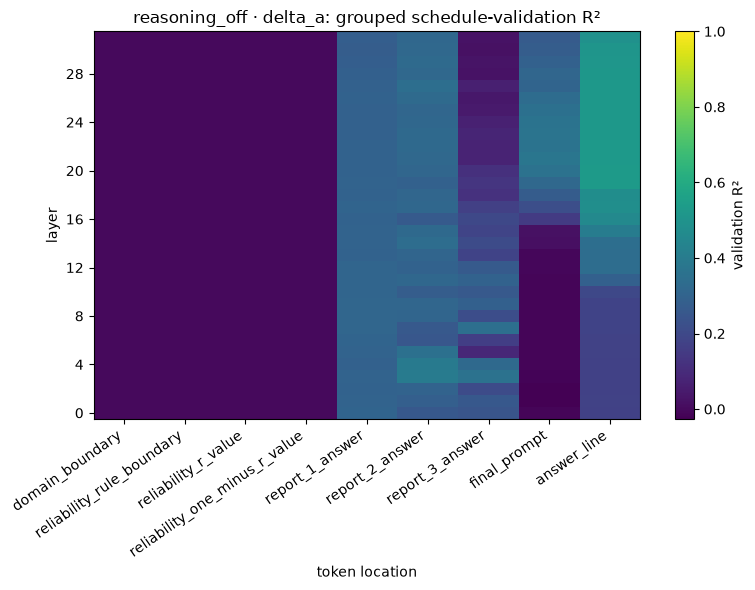

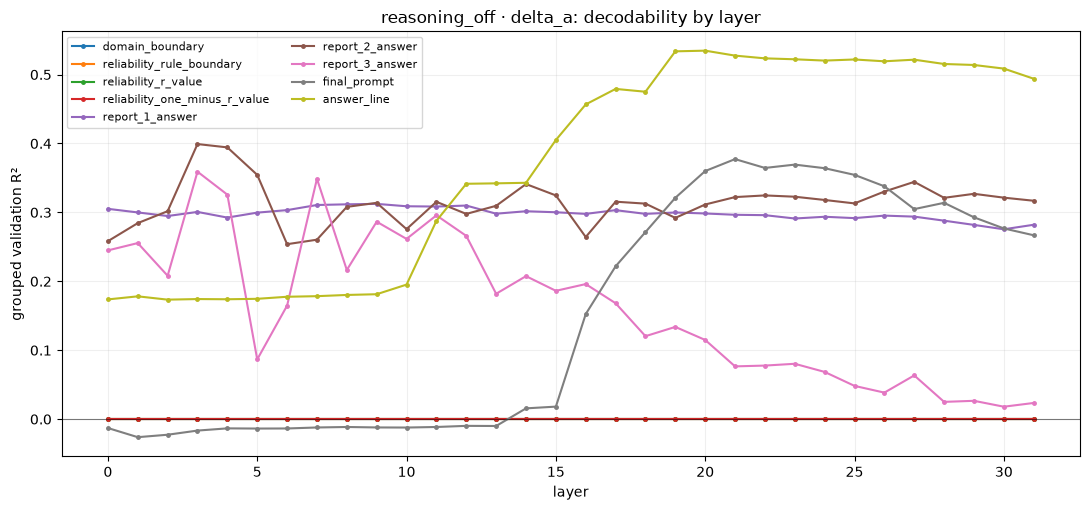

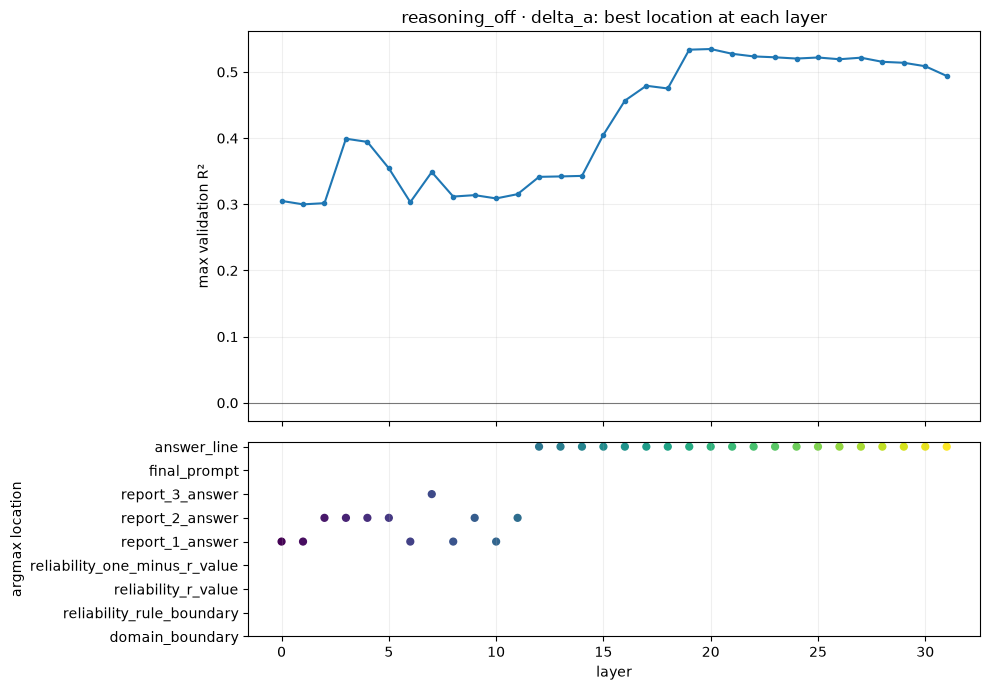

/tmp/ipykernel_405216/1379707305.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


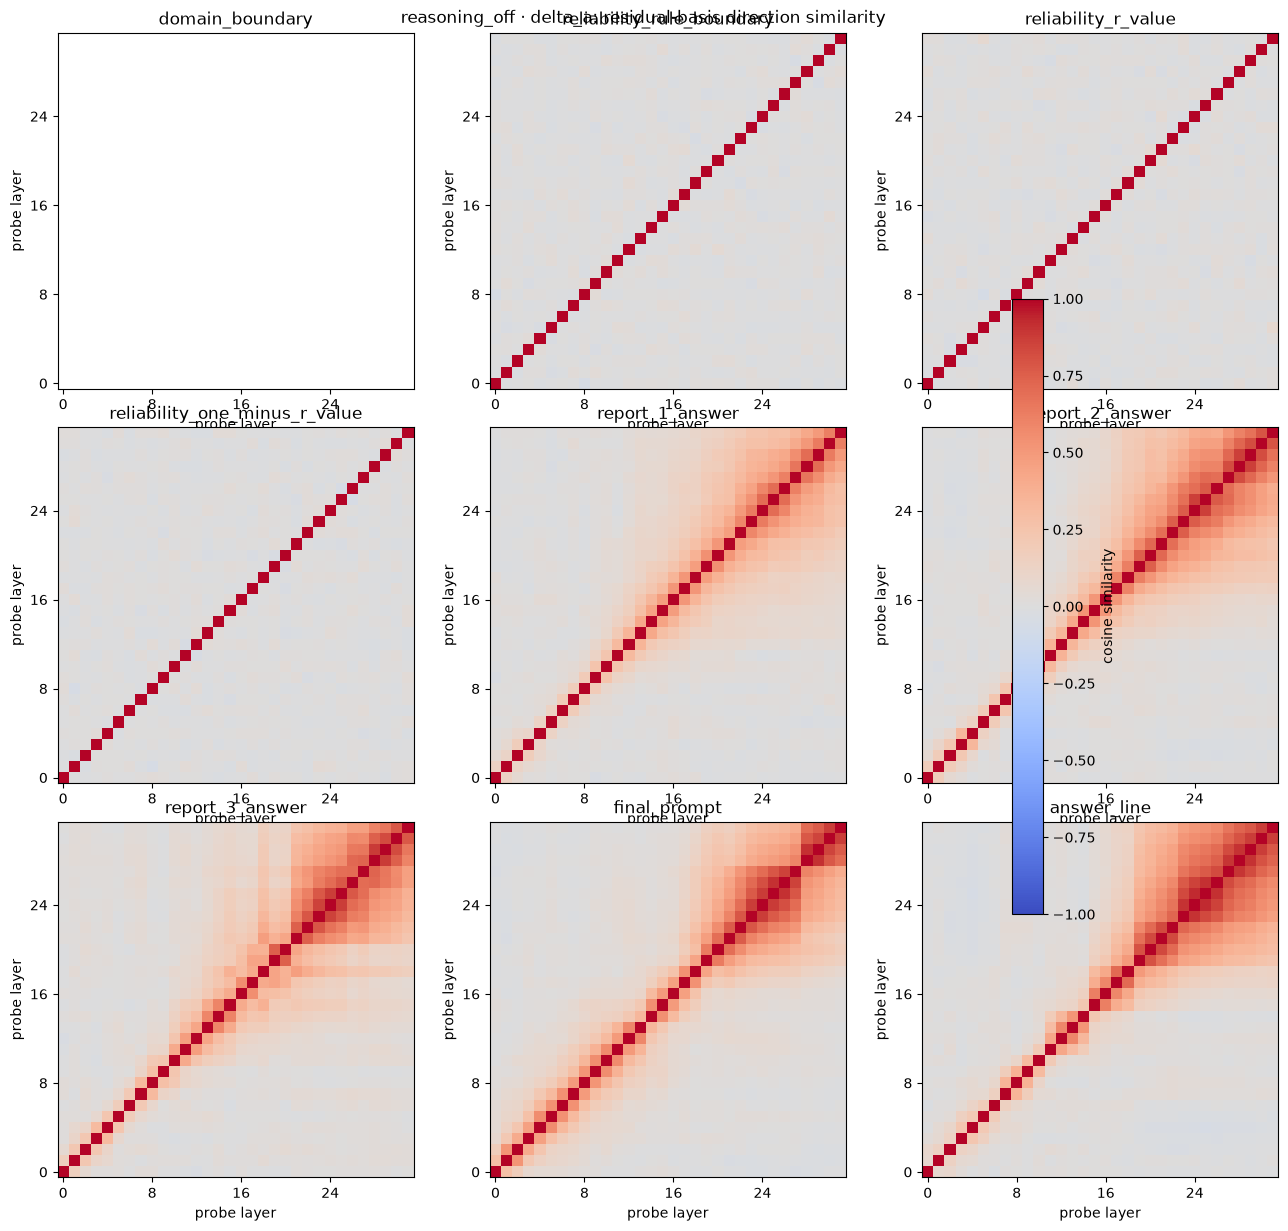

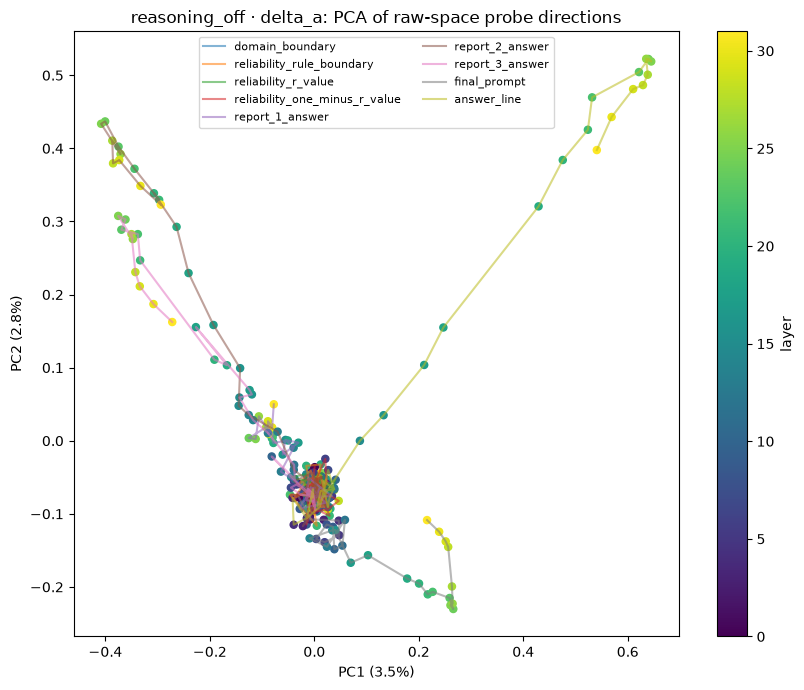

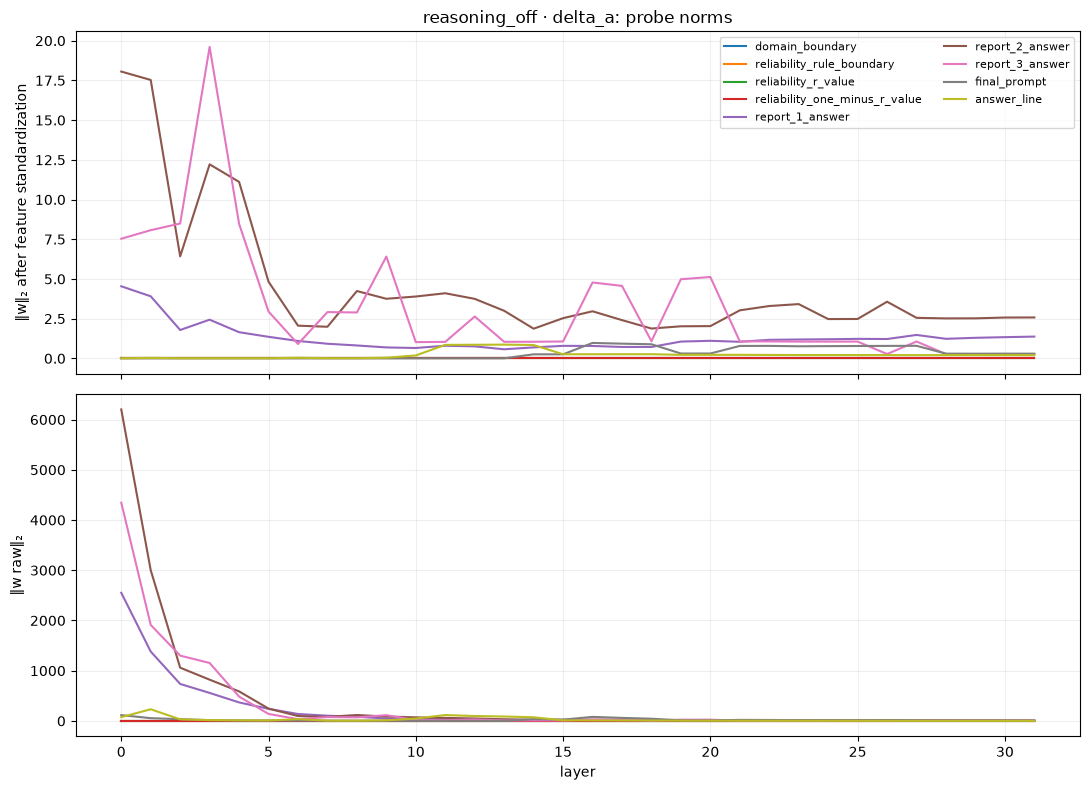

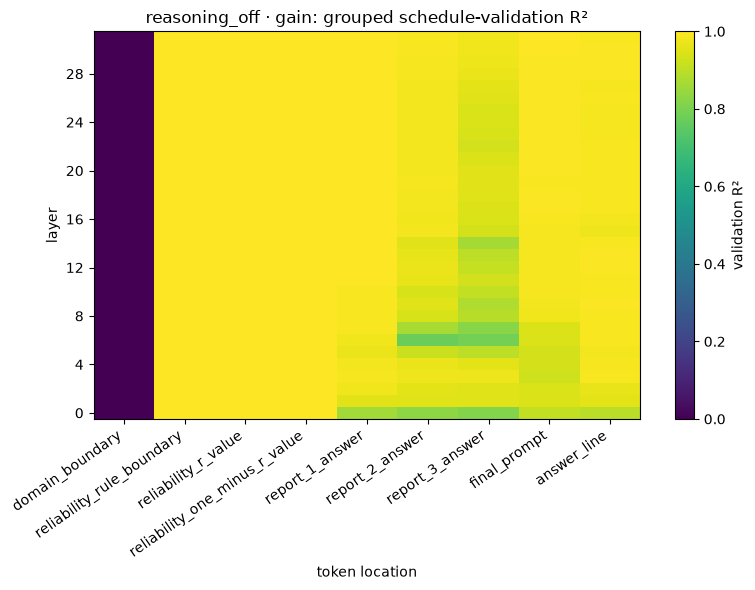

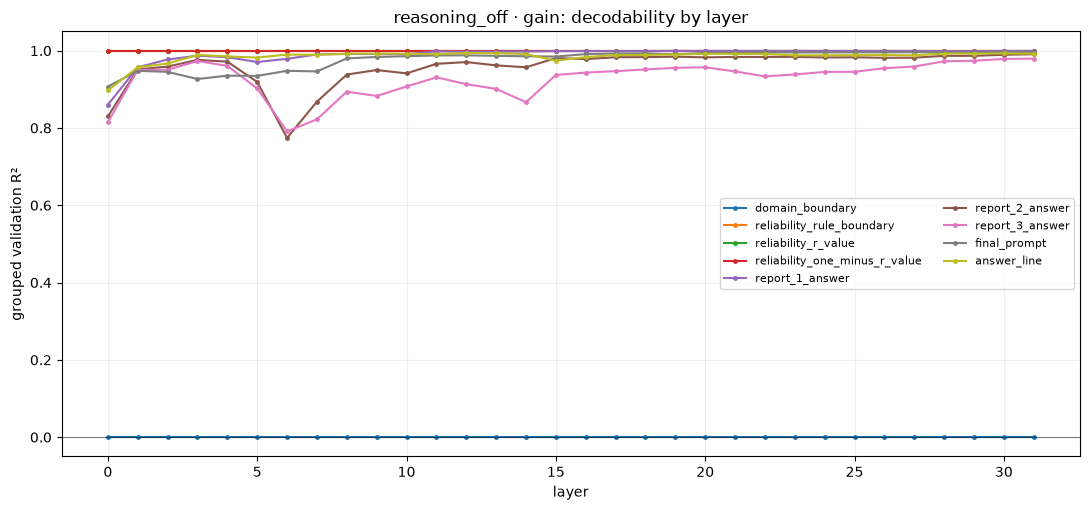

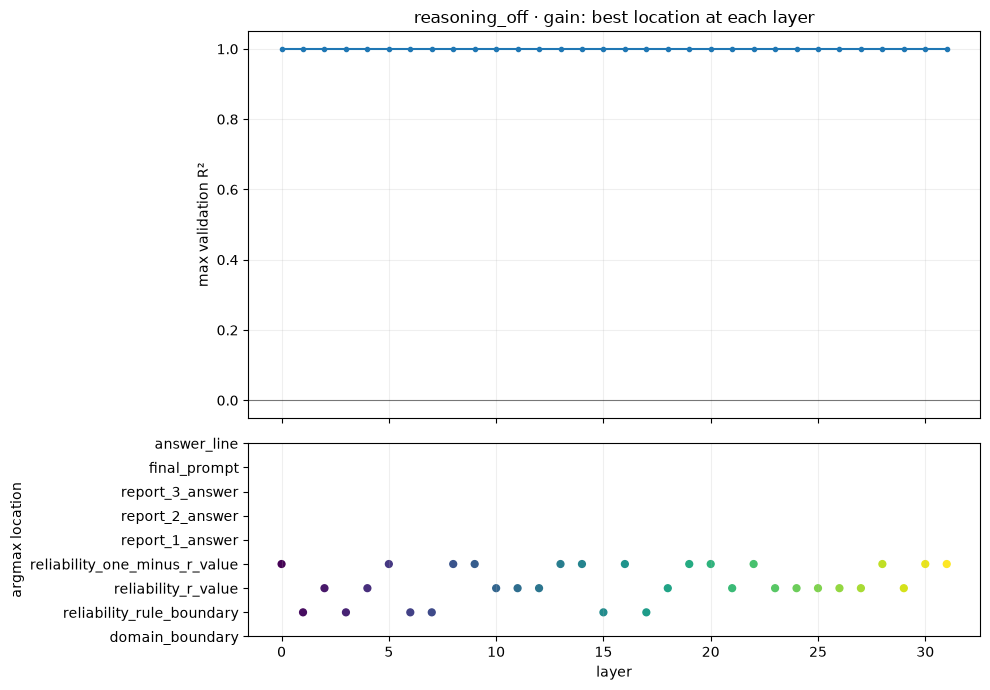

/tmp/ipykernel_405216/1379707305.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


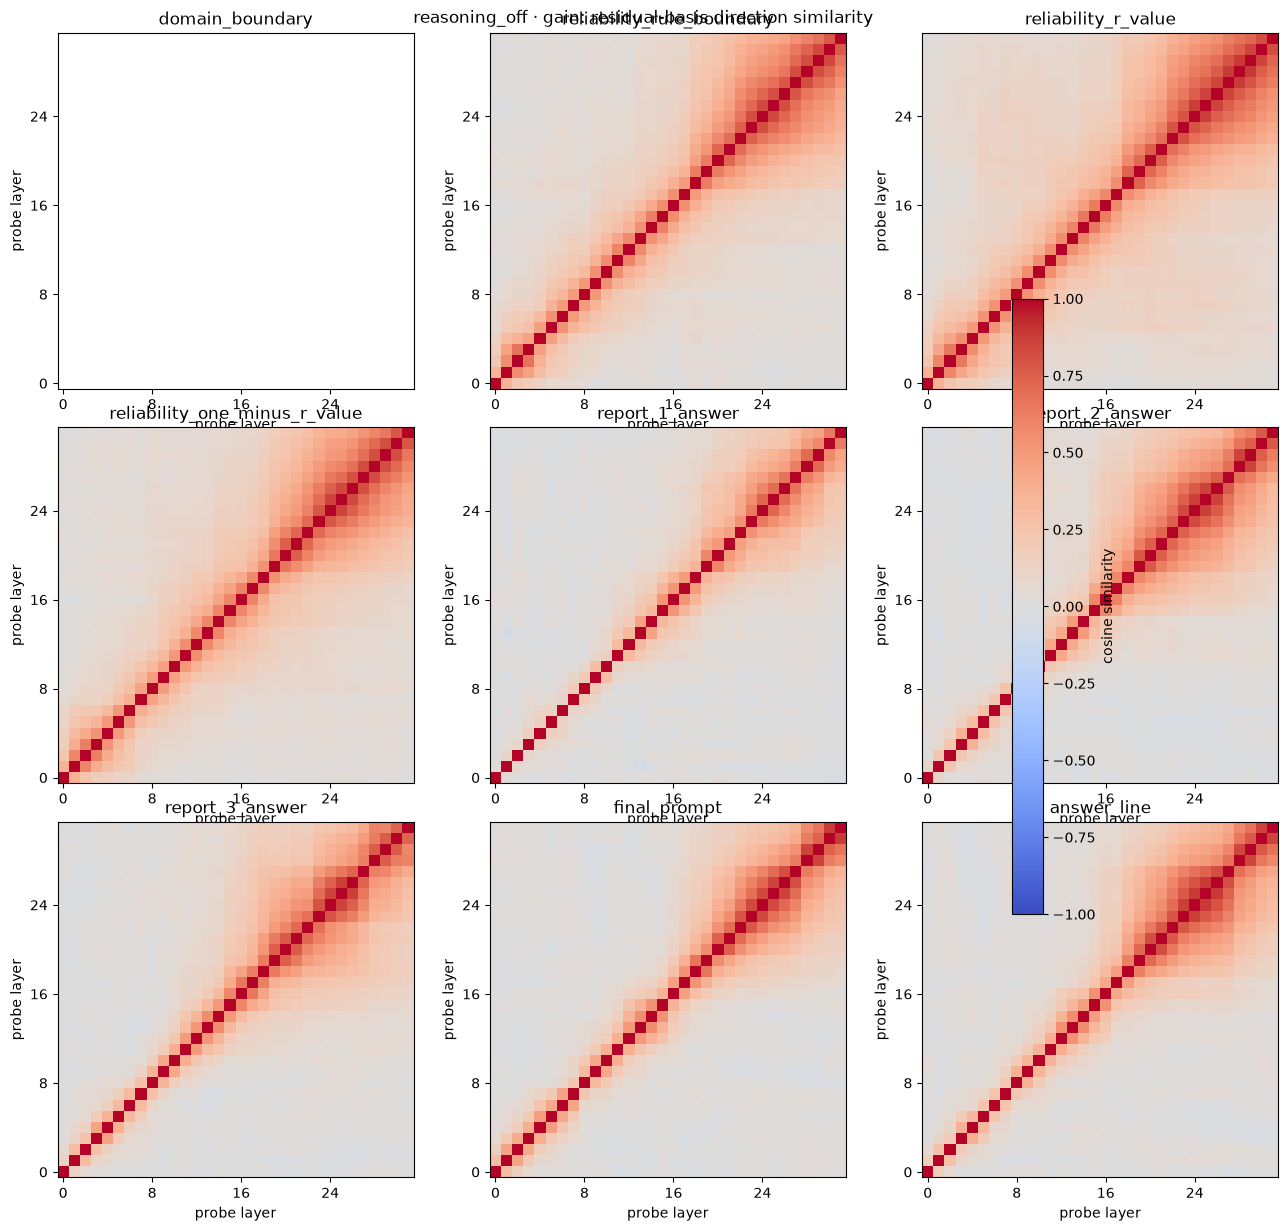

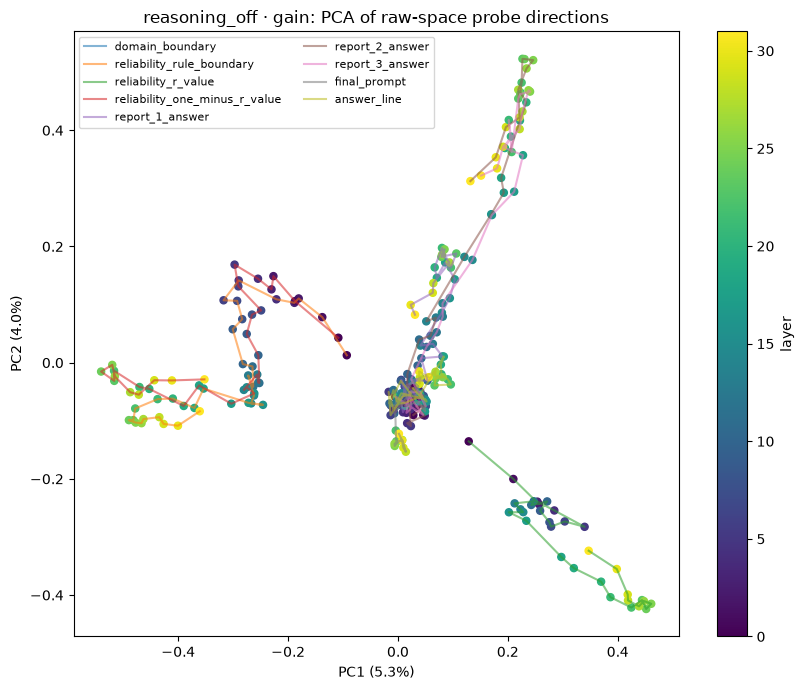

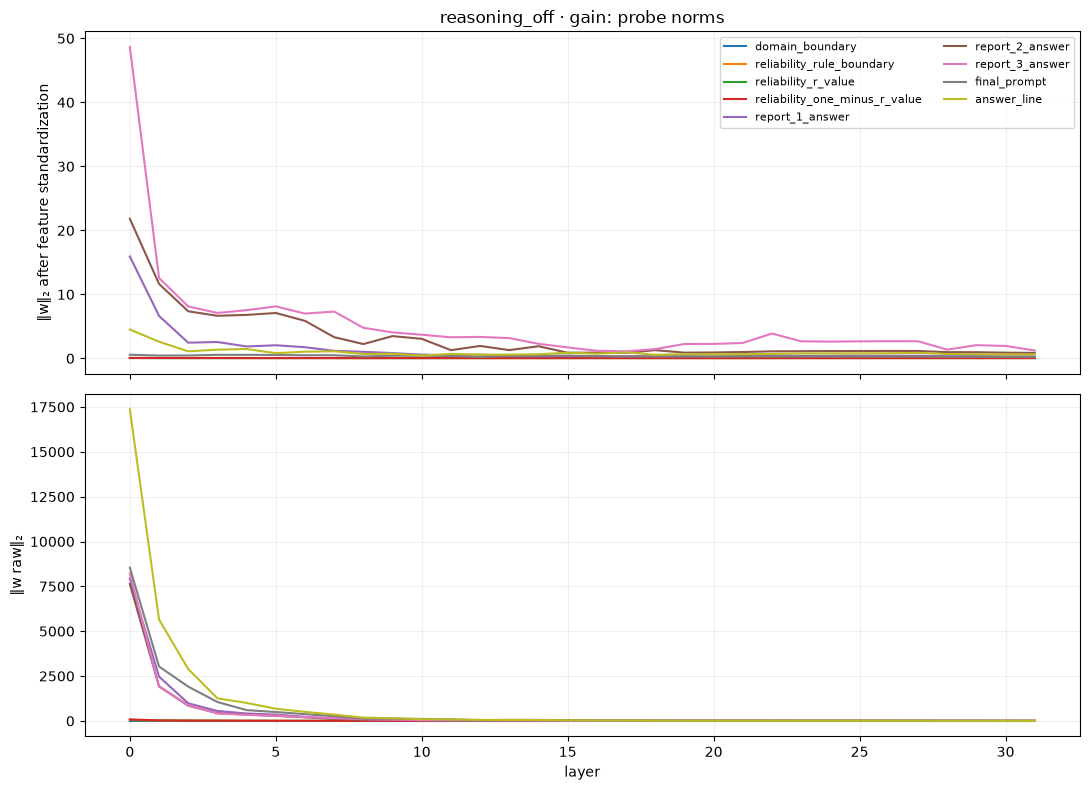

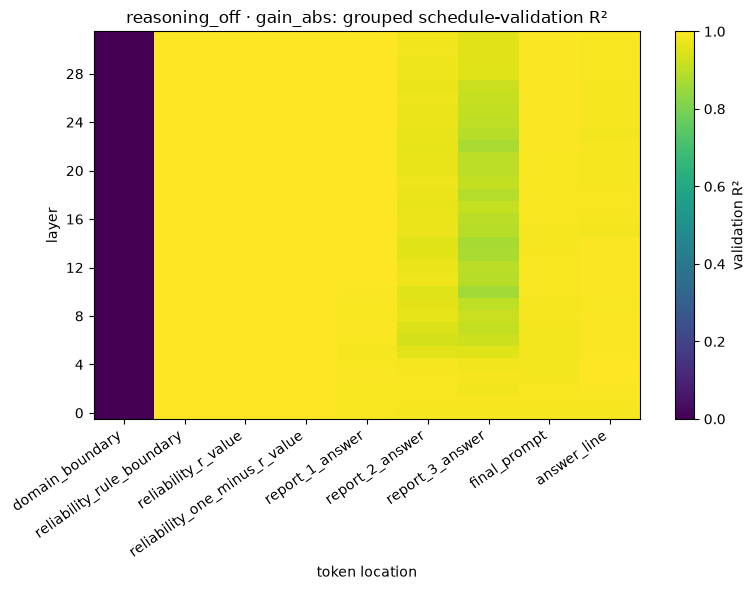

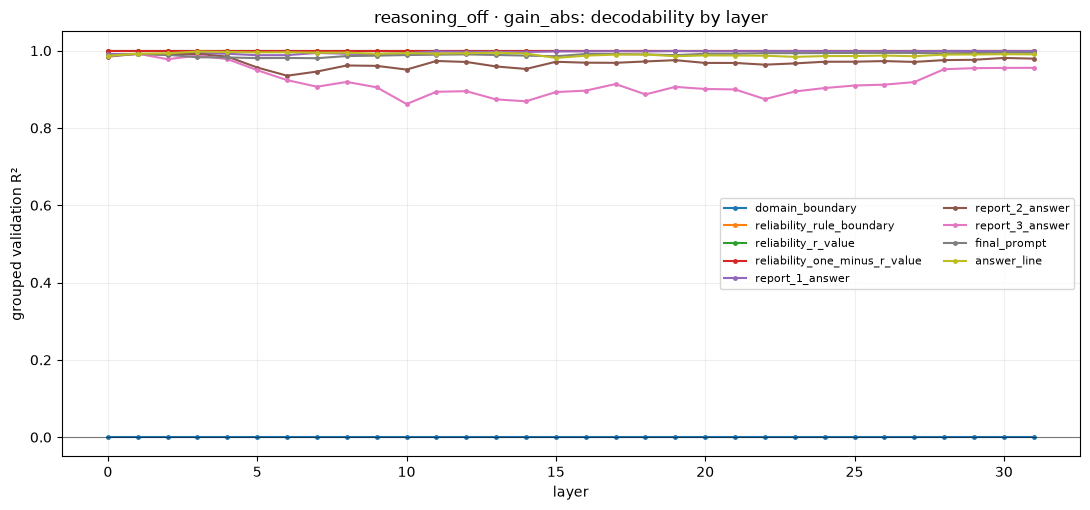

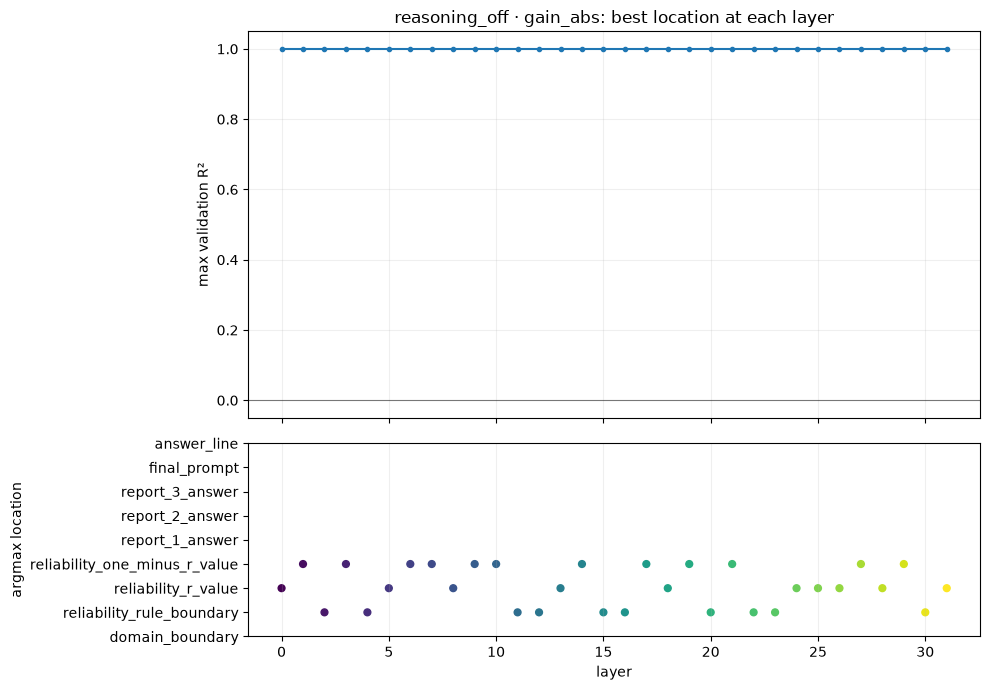

/tmp/ipykernel_405216/1379707305.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


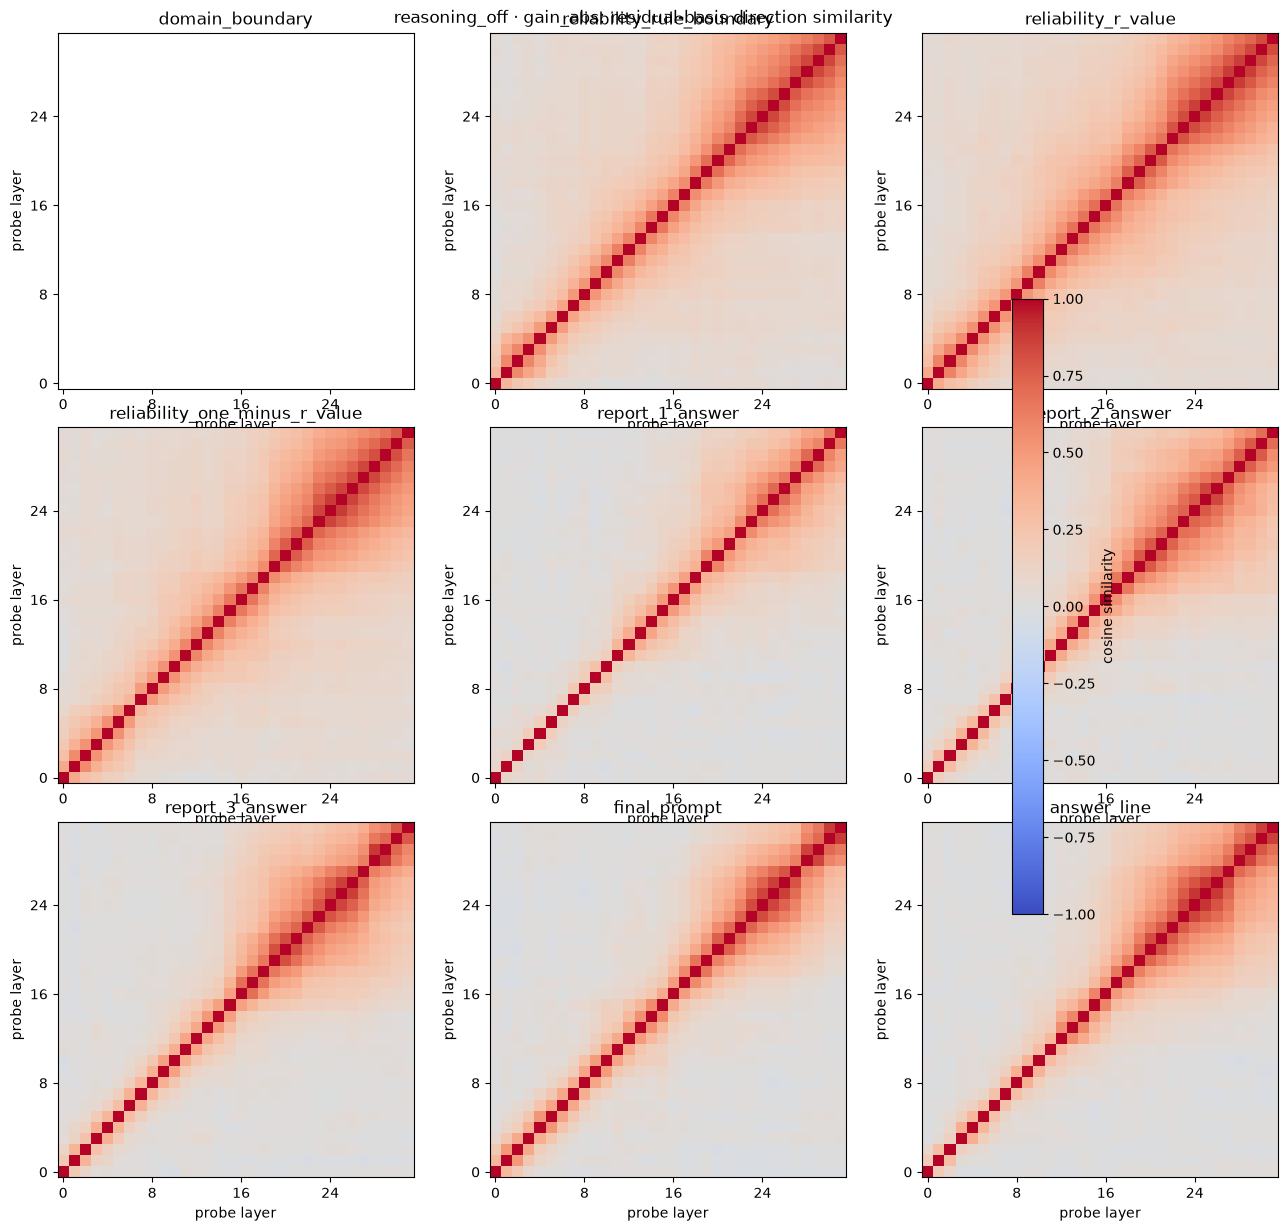

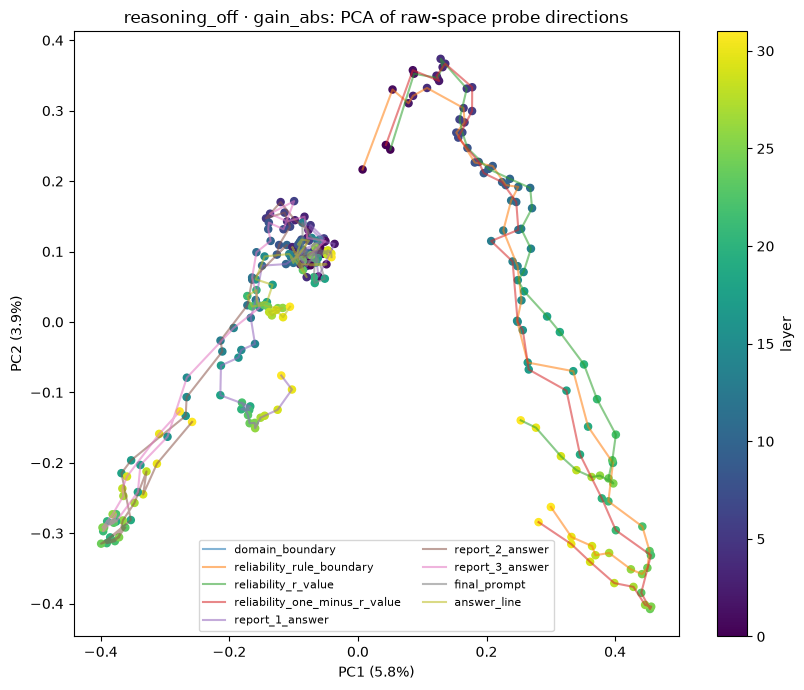

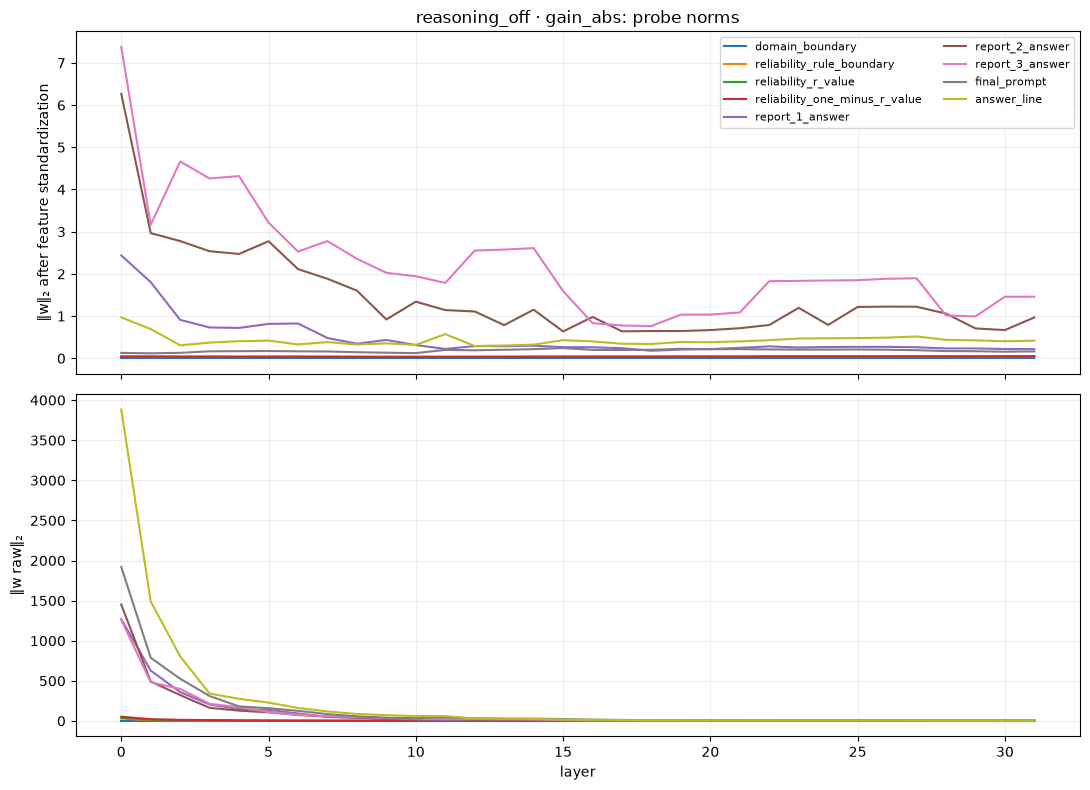

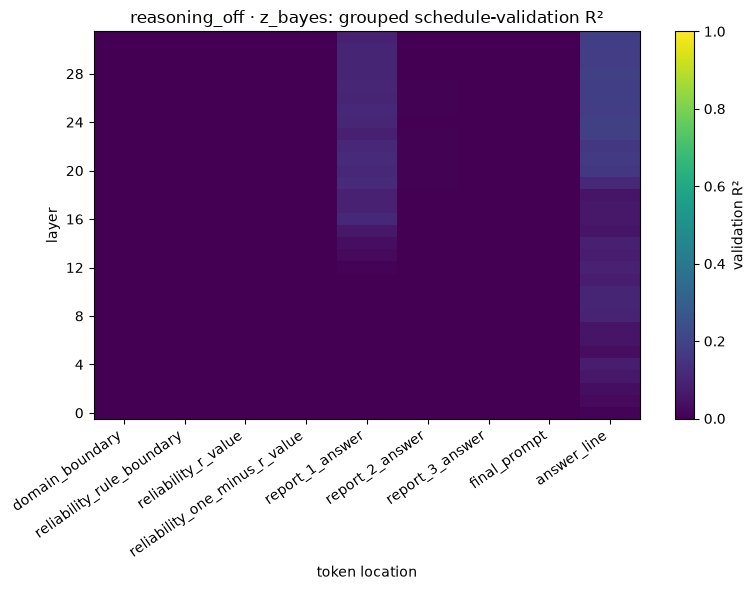

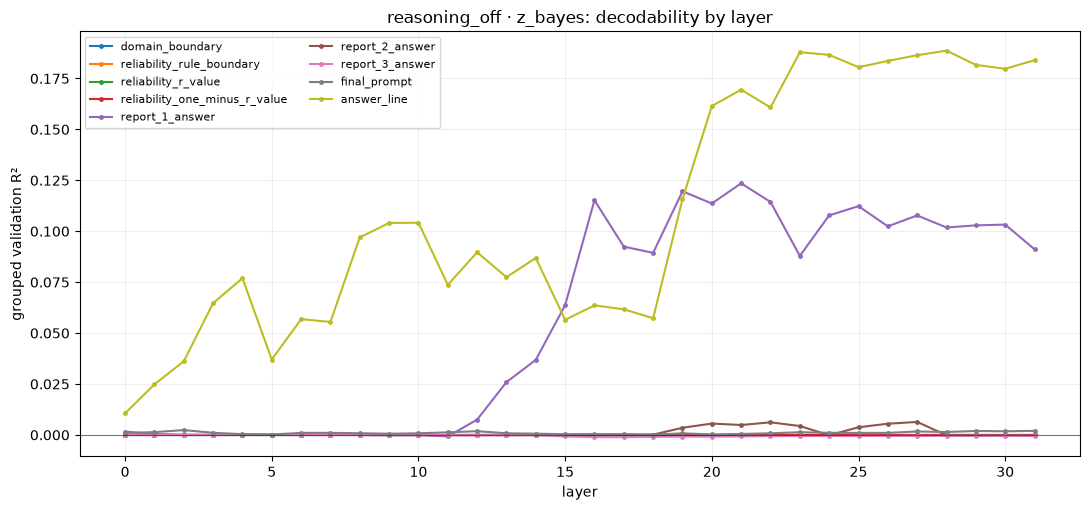

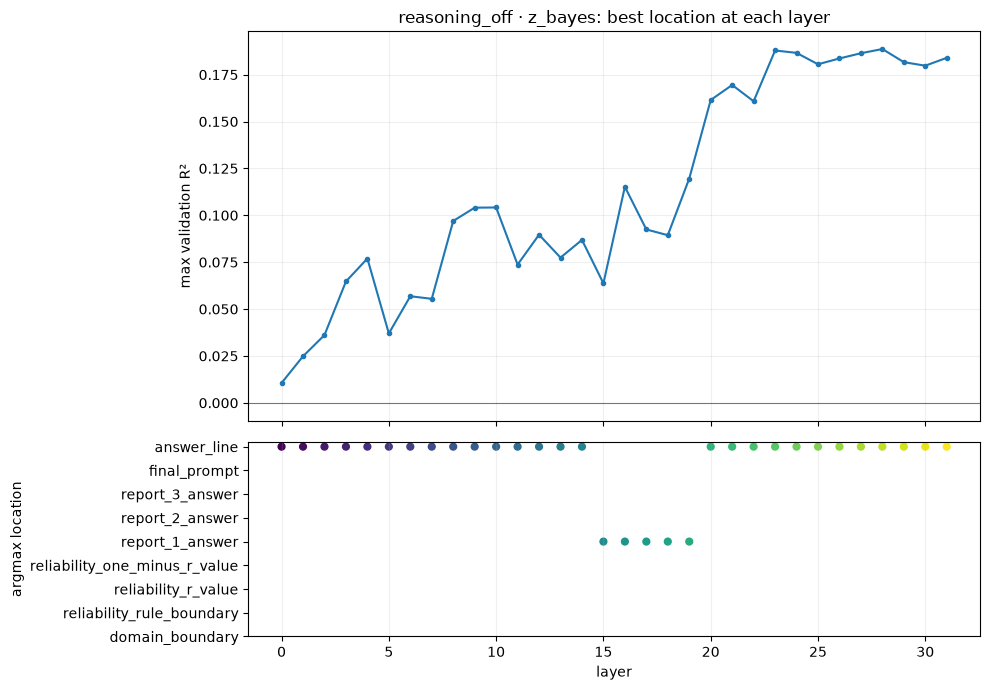

/tmp/ipykernel_405216/1379707305.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


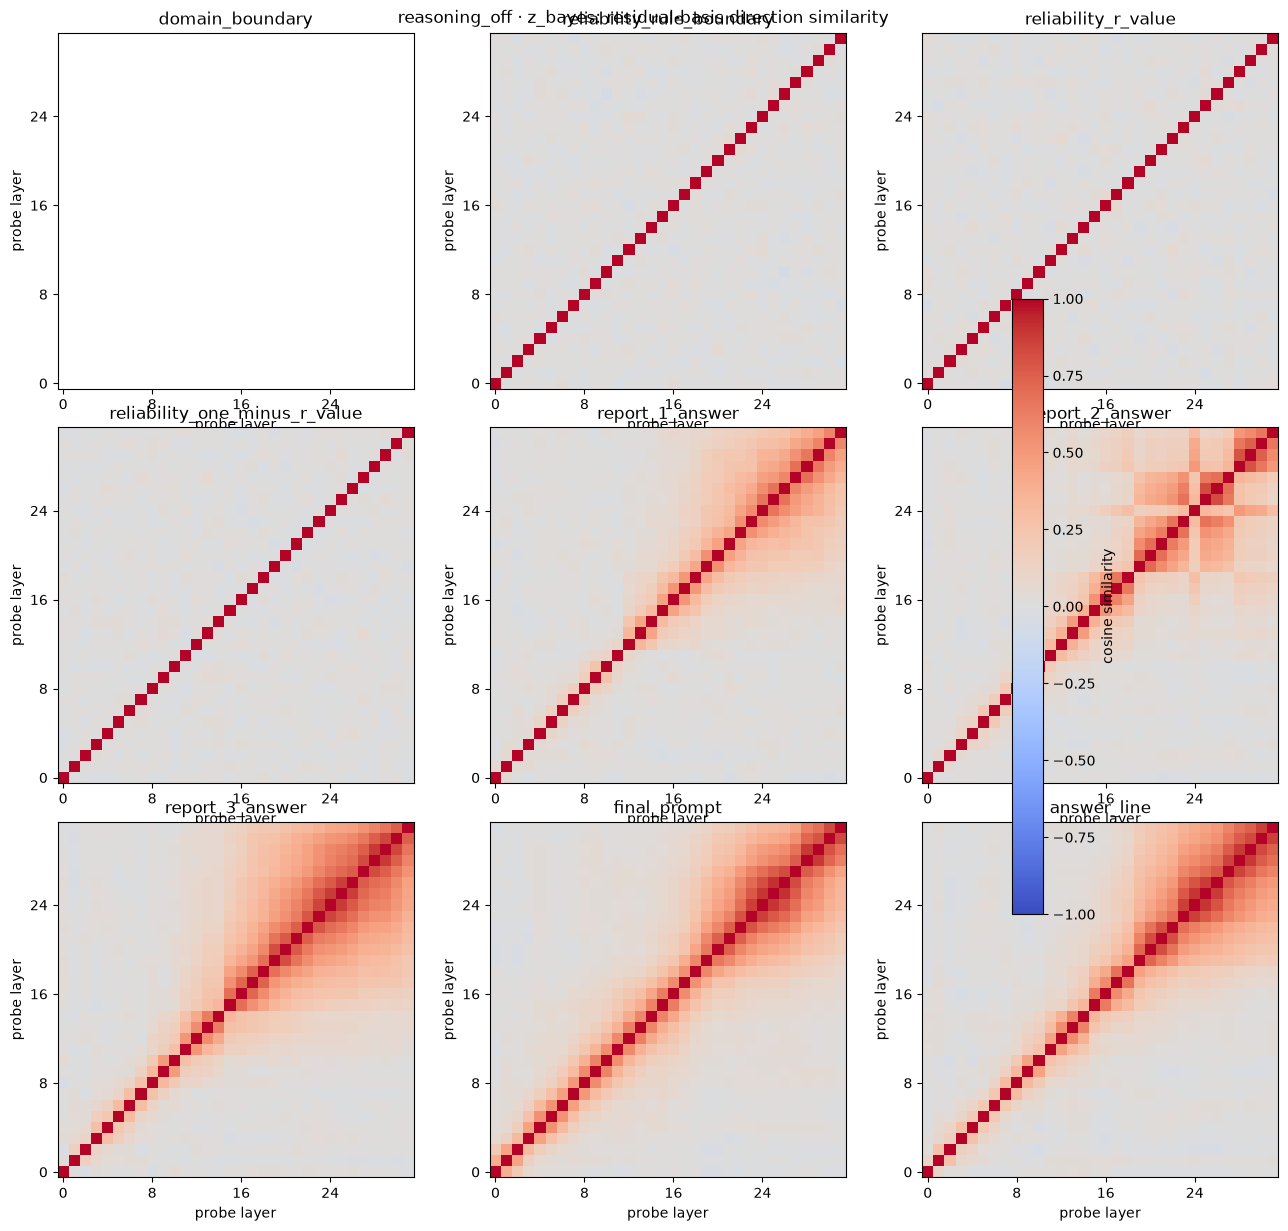

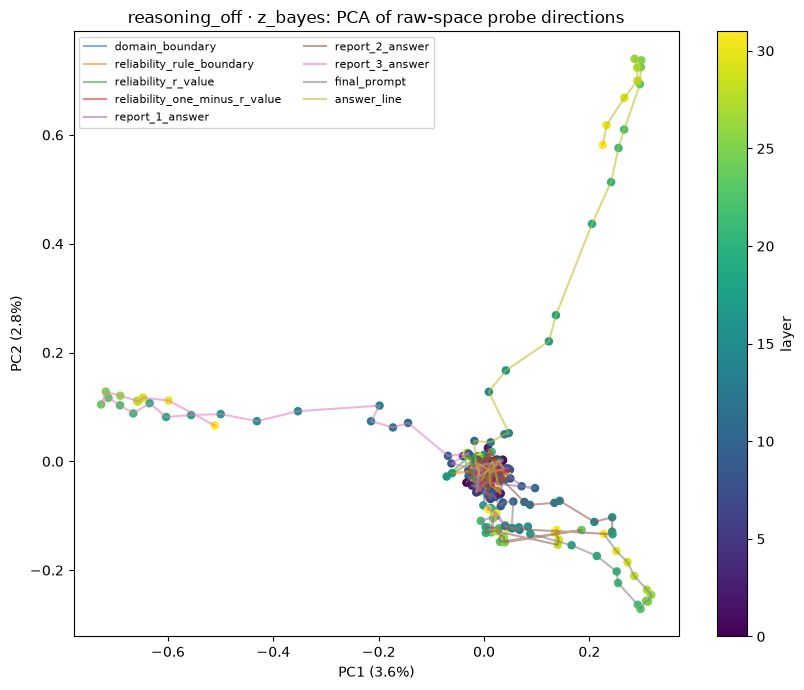

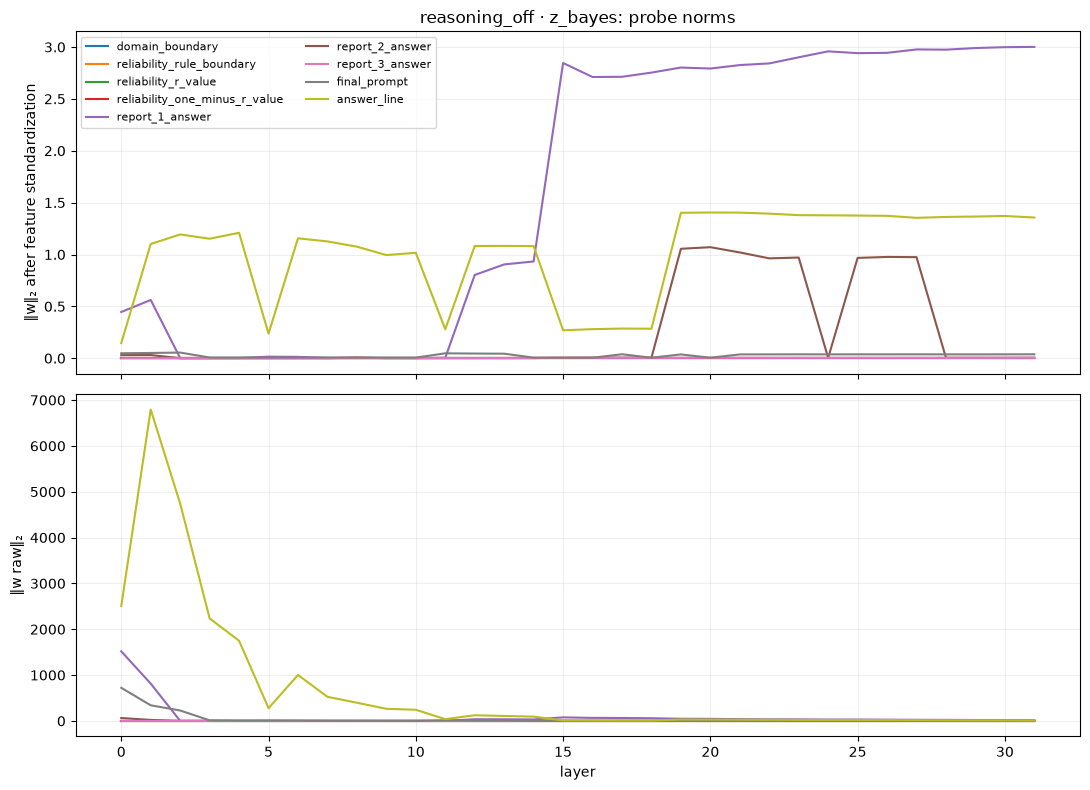

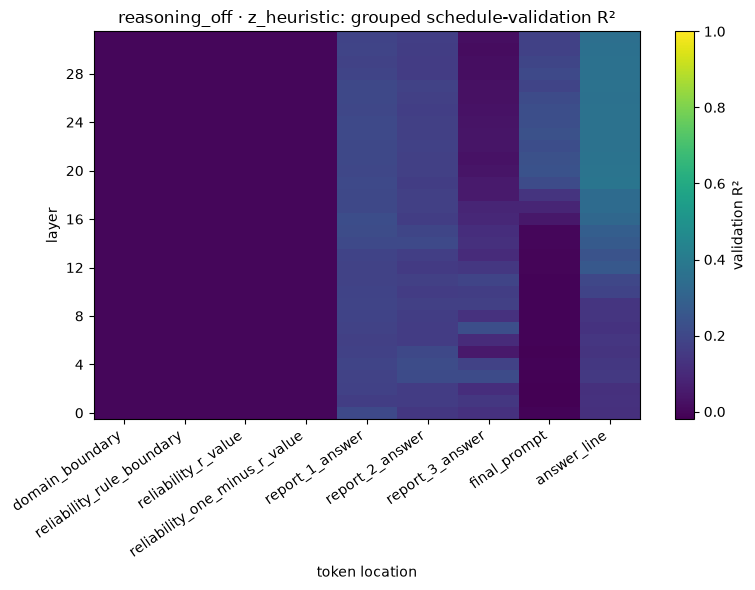

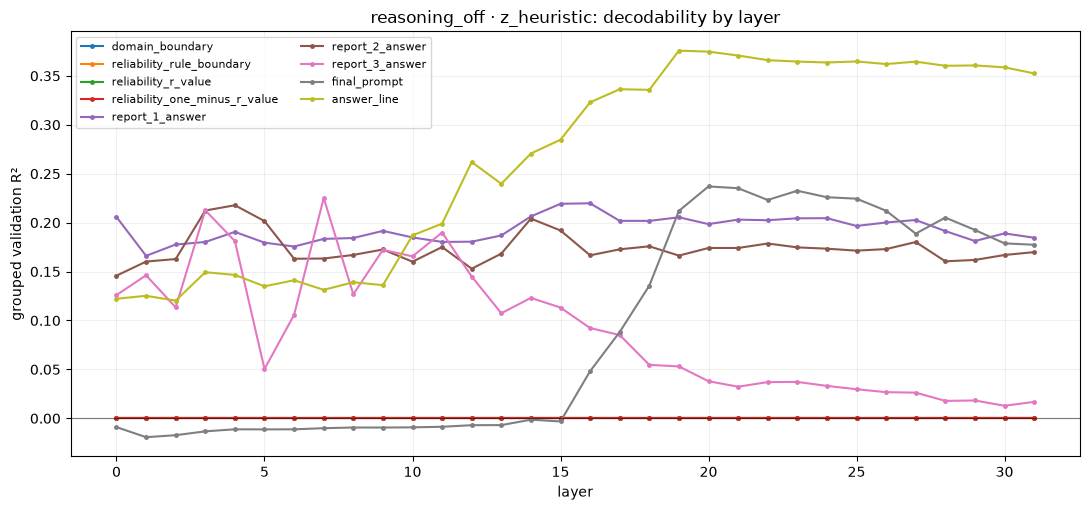

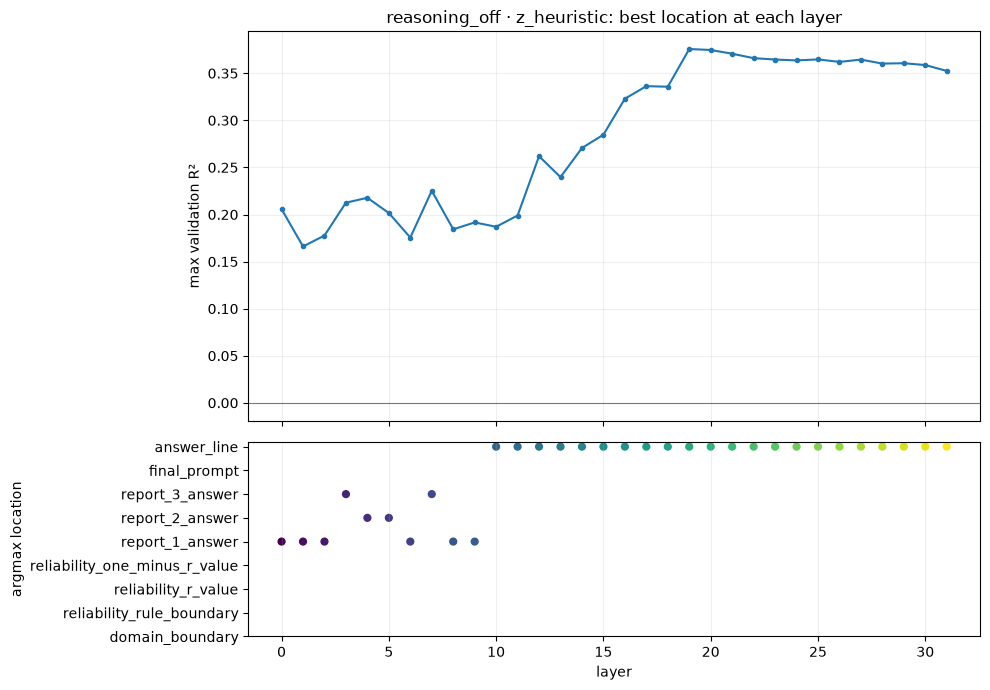

/tmp/ipykernel_405216/1379707305.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


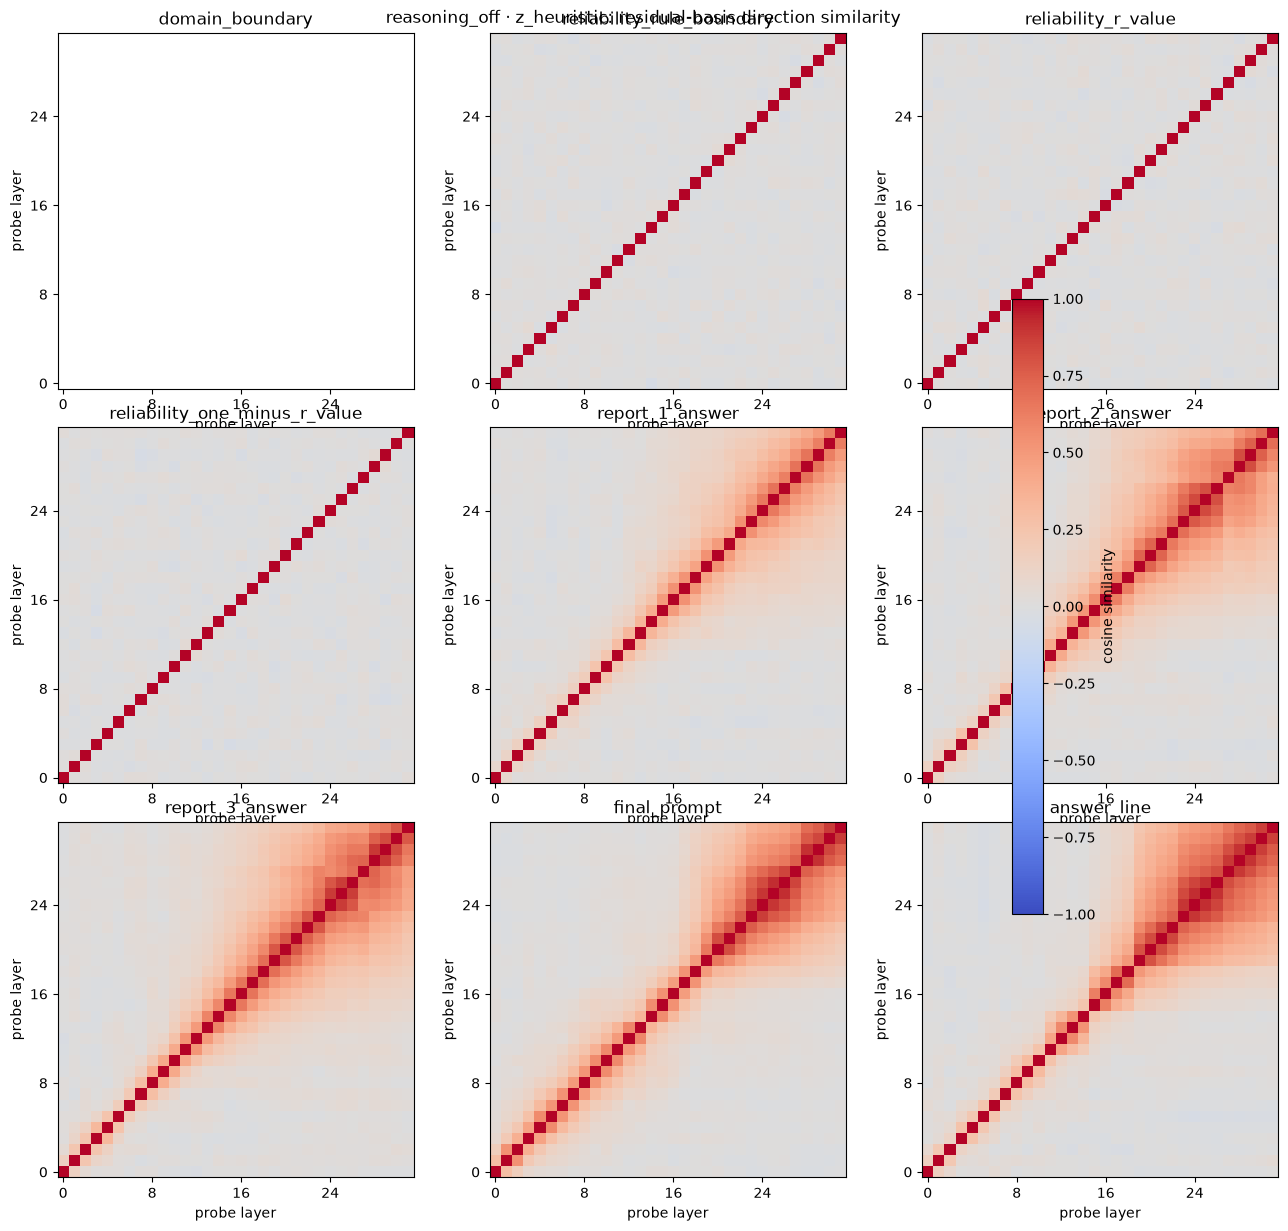

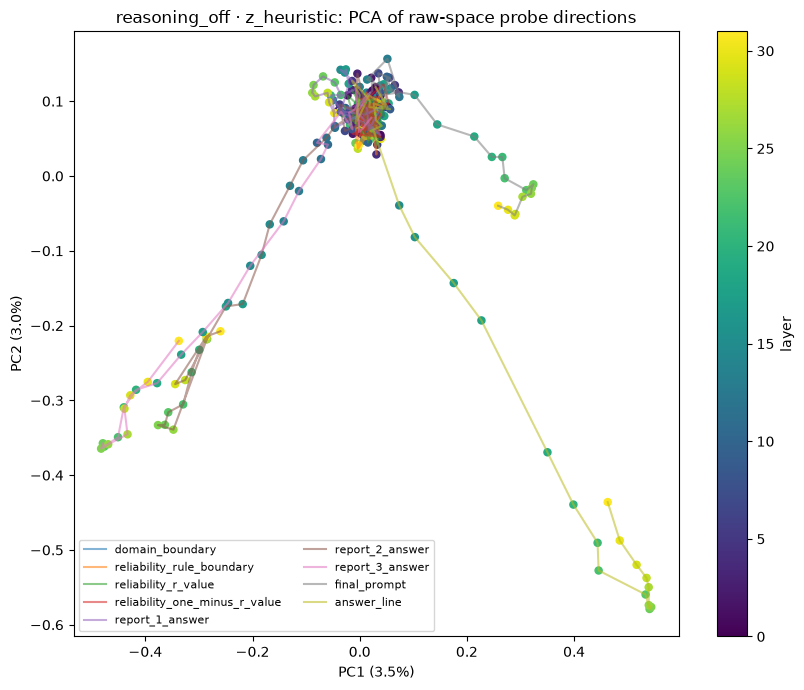

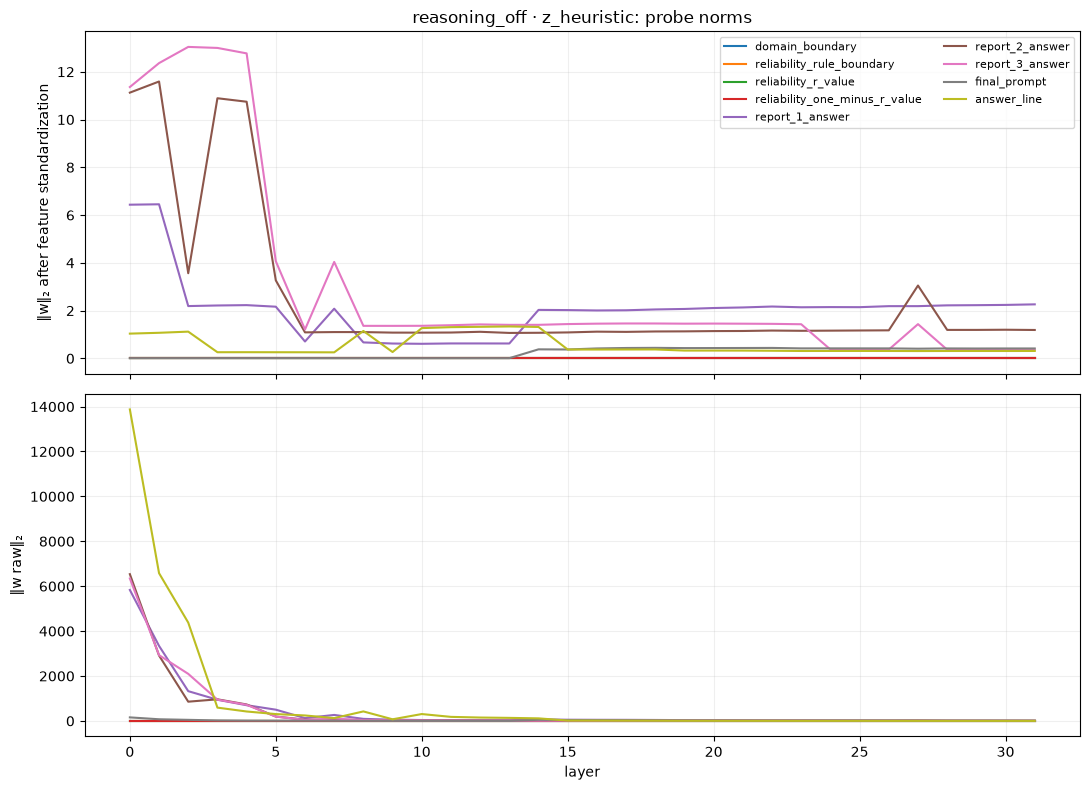

In [14]:
# 1–4, 7, and 8: training-only grouped-validation performance and probe geometry.
if RUN_PROBE_VISUALIZATIONS:
    if len(probe_cv_records) != expected_probe_count:
        raise RuntimeError("Complete the configured probe sweep before plotting it.")

    for reasoning in REASONING_VALUES:
        mode_name = MODE_NAMES[reasoning]
        for target in PROBE_PLOT_TARGETS:
            validation = grouped_validation_matrix(reasoning, target)

            # 1. Layer × location grouped-validation heatmap.
            fig, _ = draw_matrix(
                validation,
                xlabels=list(PROBE_SITES),
                ylabels=[str(layer) for layer in PROBE_LAYERS],
                title=f"{mode_name} · {target}: grouped schedule-validation R²",
                colorbar_label="validation R²",
                vmin=min(0.0, float(np.nanmin(validation))),
                vmax=1.0,
            )
            save_and_display_figure(
                fig, f"01_validation_heatmap_{mode_name}_{target}"
            )

            # 2. Probe performance versus layer.
            fig, ax = plt.subplots(figsize=(11, 5.2))
            for site_index, site in enumerate(PROBE_SITES):
                ax.plot(
                    PROBE_LAYERS, validation[:, site_index],
                    marker="o", ms=2.5, label=site,
                )
            ax.axhline(0, color="black", lw=0.8, alpha=0.5)
            ax.set(
                xlabel="layer", ylabel="grouped validation R²",
                title=f"{mode_name} · {target}: decodability by layer",
            )
            ax.legend(ncol=2, fontsize=8)
            ax.grid(alpha=0.2)
            save_and_display_figure(
                fig, f"02_validation_by_layer_{mode_name}_{target}"
            )

            # 3. Best available location and its score at each layer.
            best_location_index = np.nanargmax(validation, axis=1)
            best_score = validation[np.arange(len(PROBE_LAYERS)), best_location_index]
            fig, (score_ax, site_ax) = plt.subplots(
                2, 1, figsize=(10, 7), sharex=True,
                gridspec_kw={"height_ratios": [2, 1]},
            )
            score_ax.plot(PROBE_LAYERS, best_score, marker="o", ms=3)
            score_ax.axhline(0, color="black", lw=0.8, alpha=0.5)
            score_ax.set(
                ylabel="max validation R²",
                title=f"{mode_name} · {target}: best location at each layer",
            )
            score_ax.grid(alpha=0.2)
            site_ax.scatter(
                PROBE_LAYERS, best_location_index,
                c=PROBE_LAYERS, cmap="viridis", s=24,
            )
            site_ax.set_yticks(np.arange(len(PROBE_SITES)), labels=PROBE_SITES)
            site_ax.set(xlabel="layer", ylabel="argmax location")
            site_ax.grid(axis="x", alpha=0.2)
            save_and_display_figure(
                fig, f"03_best_location_by_layer_{mode_name}_{target}"
            )

            # 4. Pairwise cosine similarity, one compact panel per location.
            n_columns = 3
            n_rows = math.ceil(len(PROBE_SITES) / n_columns)
            fig, axes = plt.subplots(
                n_rows, n_columns, figsize=(13, 4.1 * n_rows), squeeze=False
            )
            for site_index, site in enumerate(PROBE_SITES):
                directions = np.stack([
                    normalized_raw_direction(
                        reasoning=reasoning, site=site,
                        target=target, layer=int(layer),
                    )
                    for layer in PROBE_LAYERS
                ])
                similarity = directions @ directions.T
                ax = axes.flat[site_index]
                image = ax.imshow(
                    similarity, origin="lower", vmin=-1, vmax=1, cmap="coolwarm"
                )
                ax.set(xlabel="probe layer", ylabel="probe layer", title=site)
                ticks = np.arange(0, len(PROBE_LAYERS), 8)
                ax.set_xticks(ticks, labels=[PROBE_LAYERS[i] for i in ticks])
                ax.set_yticks(ticks, labels=[PROBE_LAYERS[i] for i in ticks])
            for ax in axes.flat[len(PROBE_SITES):]:
                ax.set_visible(False)
            fig.colorbar(image, ax=list(axes.flat), label="cosine similarity", shrink=0.65)
            fig.suptitle(
                f"{mode_name} · {target}: residual-basis direction similarity"
            )
            save_and_display_figure(
                fig, f"04_direction_cosine_{mode_name}_{target}"
            )

            # 7. PCA trajectory of every normalized layer/location direction.
            direction_rows = []
            for site in PROBE_SITES:
                for layer in PROBE_LAYERS:
                    direction_rows.append((
                        site, int(layer),
                        normalized_raw_direction(
                            reasoning=reasoning, site=site,
                            target=target, layer=int(layer),
                        ),
                    ))
            direction_matrix = np.stack([row[2] for row in direction_rows])
            finite = np.isfinite(direction_matrix).all(axis=1)
            direction_rows = [row for row, keep in zip(direction_rows, finite) if keep]
            direction_matrix = direction_matrix[finite]
            pca = PCA(n_components=2, random_state=SEED)
            coordinates = pca.fit_transform(direction_matrix)
            fig, ax = plt.subplots(figsize=(8.5, 7.0))
            for site in PROBE_SITES:
                mask = np.asarray([row[0] == site for row in direction_rows])
                layers = np.asarray([row[1] for row in direction_rows])[mask]
                order = np.argsort(layers)
                points = coordinates[mask][order]
                layers = layers[order]
                ax.plot(points[:, 0], points[:, 1], alpha=0.55, label=site)
                scatter = ax.scatter(
                    points[:, 0], points[:, 1], c=layers,
                    cmap="viridis", s=26,
                )
            ax.set(
                xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
                ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
                title=f"{mode_name} · {target}: PCA of raw-space probe directions",
            )
            ax.legend(ncol=2, fontsize=8)
            fig.colorbar(scatter, ax=ax, label="layer")
            save_and_display_figure(
                fig, f"07_direction_pca_{mode_name}_{target}"
            )

            # 8. Standardized-coordinate and raw-space norms.
            fig, (standard_ax, raw_ax) = plt.subplots(
                2, 1, figsize=(11, 8), sharex=True
            )
            for site in PROBE_SITES:
                parameters = [
                    probe_affine_parameters(
                        reasoning=reasoning, site=site,
                        target=target, layer=int(layer),
                    )
                    for layer in PROBE_LAYERS
                ]
                standard_ax.plot(PROBE_LAYERS, [
                    np.linalg.norm(np.asarray(item["standardized_coef"]))
                    for item in parameters
                ], label=site)
                raw_ax.plot(PROBE_LAYERS, [
                    np.linalg.norm(np.asarray(item["raw_direction"]))
                    for item in parameters
                ], label=site)
            standard_ax.set(
                ylabel="‖w‖₂ after feature standardization",
                title=f"{mode_name} · {target}: probe norms",
            )
            raw_ax.set(xlabel="layer", ylabel="‖w raw‖₂")
            standard_ax.legend(ncol=2, fontsize=8)
            for ax in (standard_ax, raw_ax):
                ax.grid(alpha=0.2)
            save_and_display_figure(
                fig, f"08_probe_norm_{mode_name}_{target}"
            )
else:
    print("Probe visualizations are paused: RUN_PROBE_VISUALIZATIONS=False.")


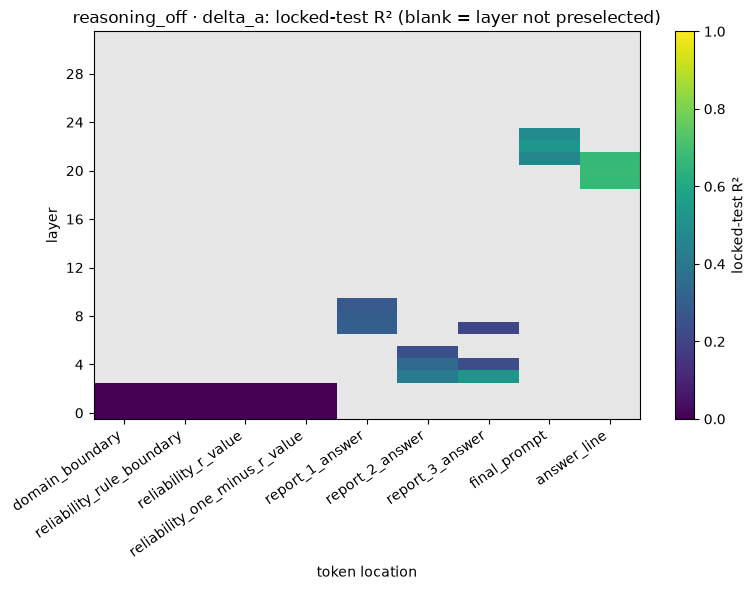

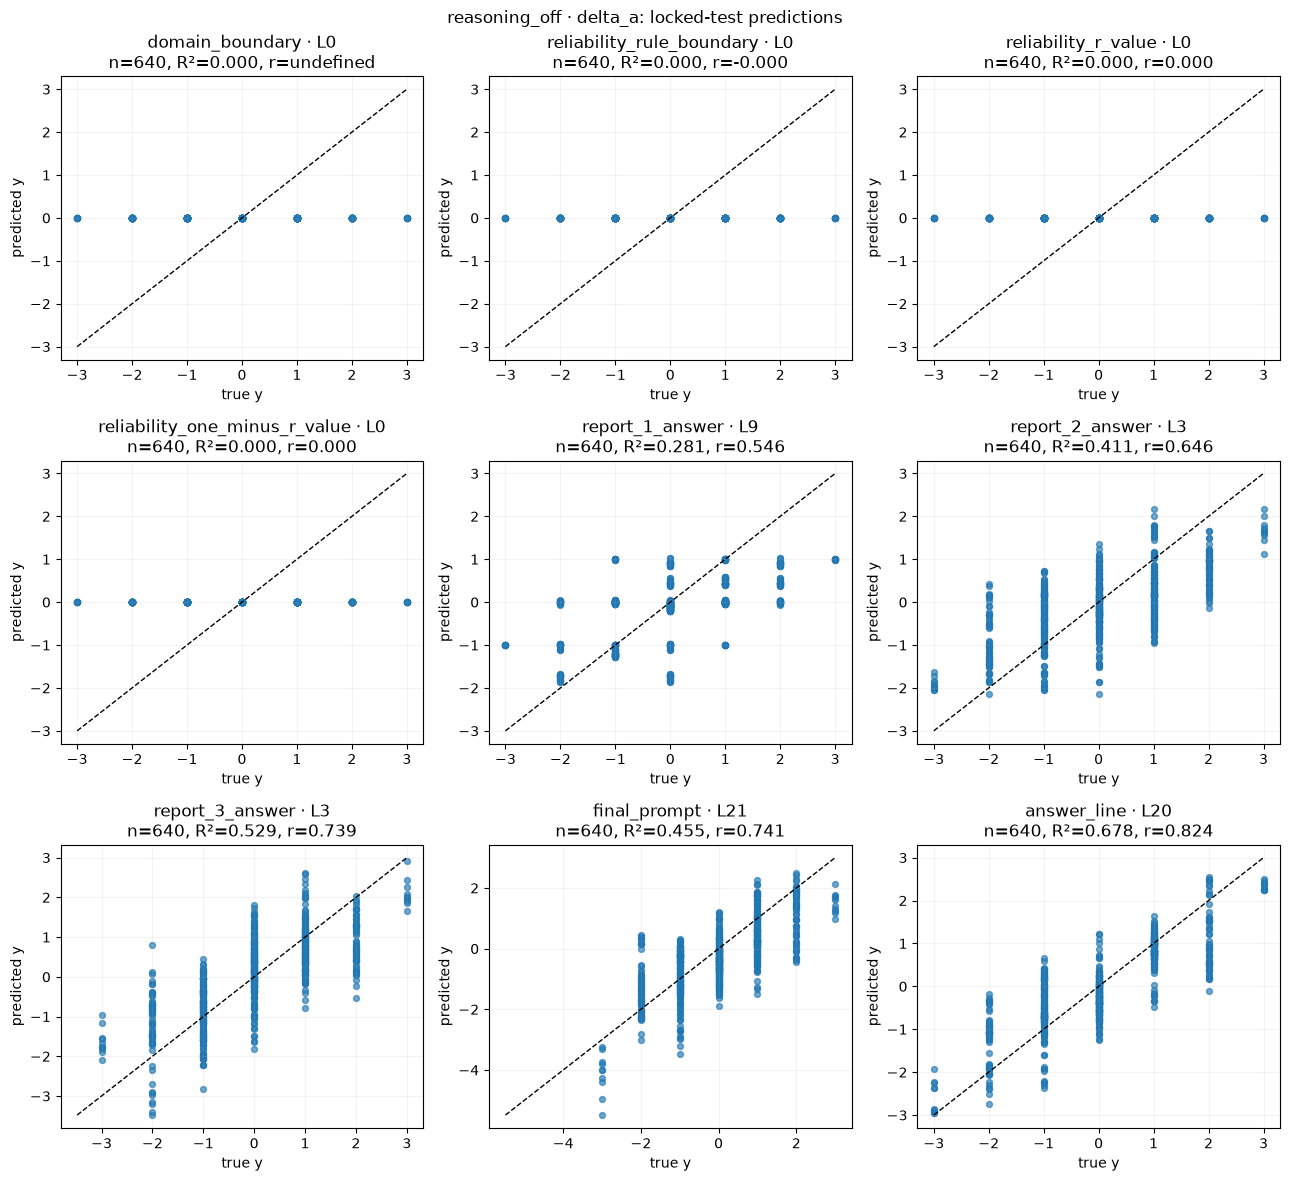

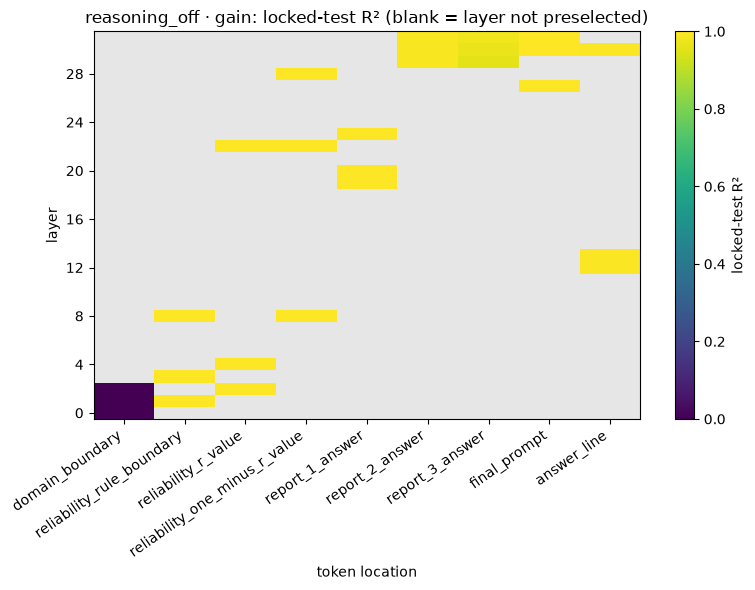

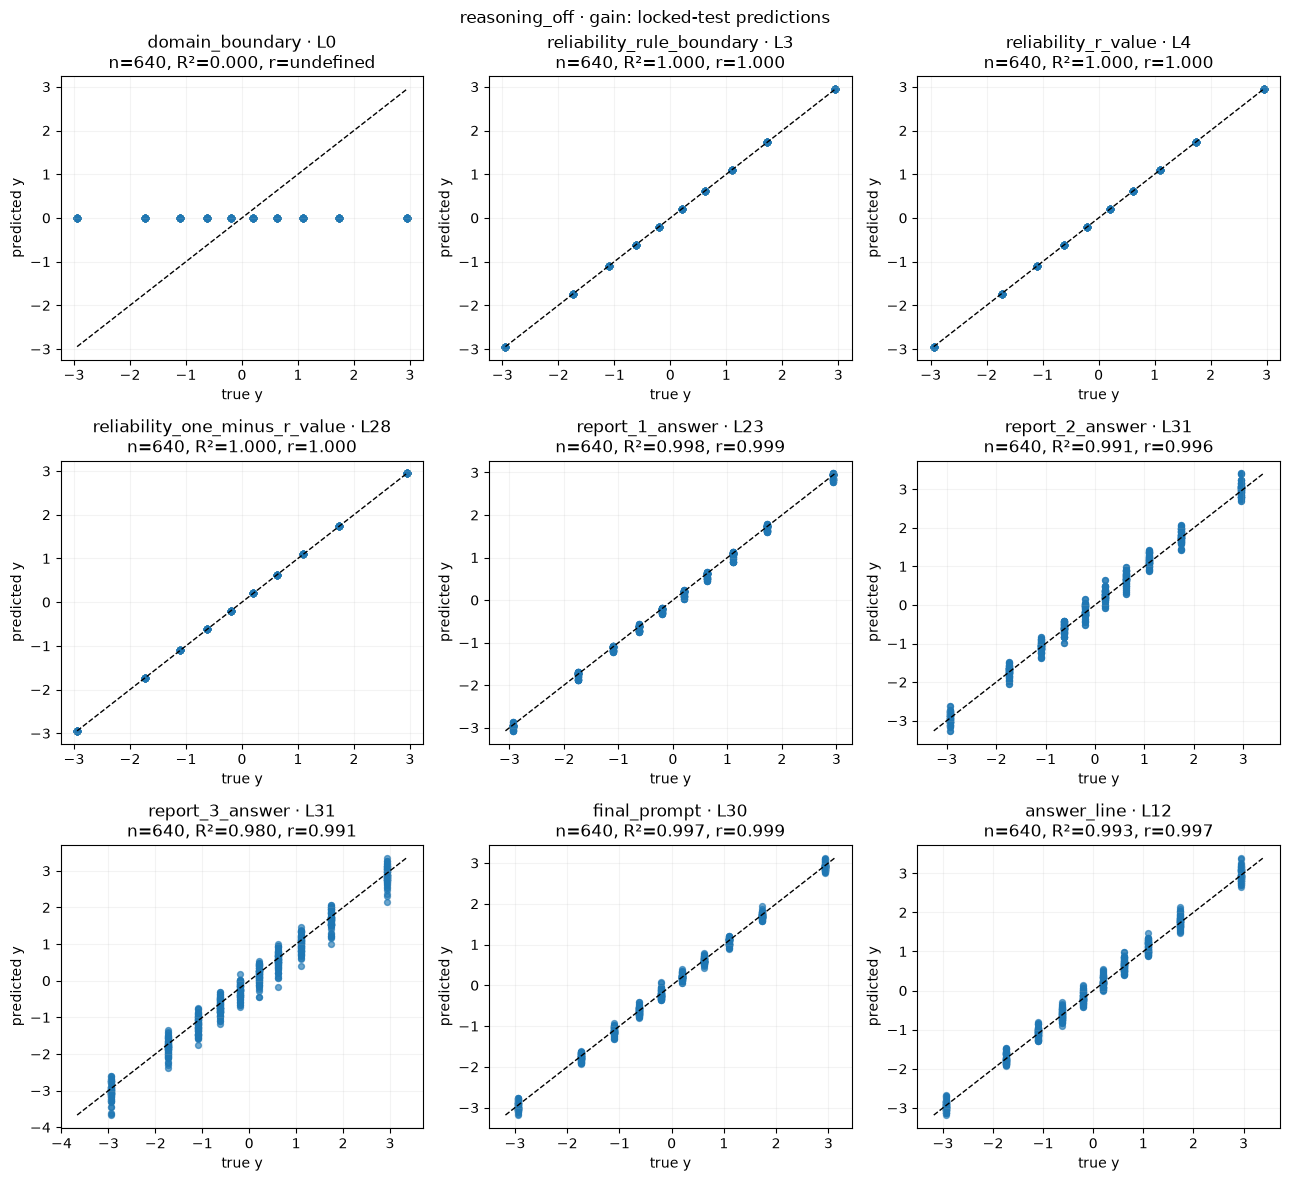

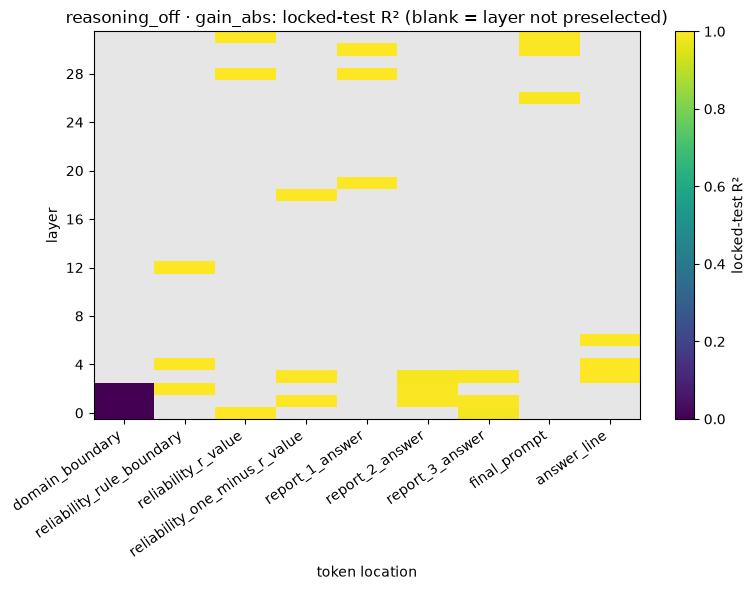

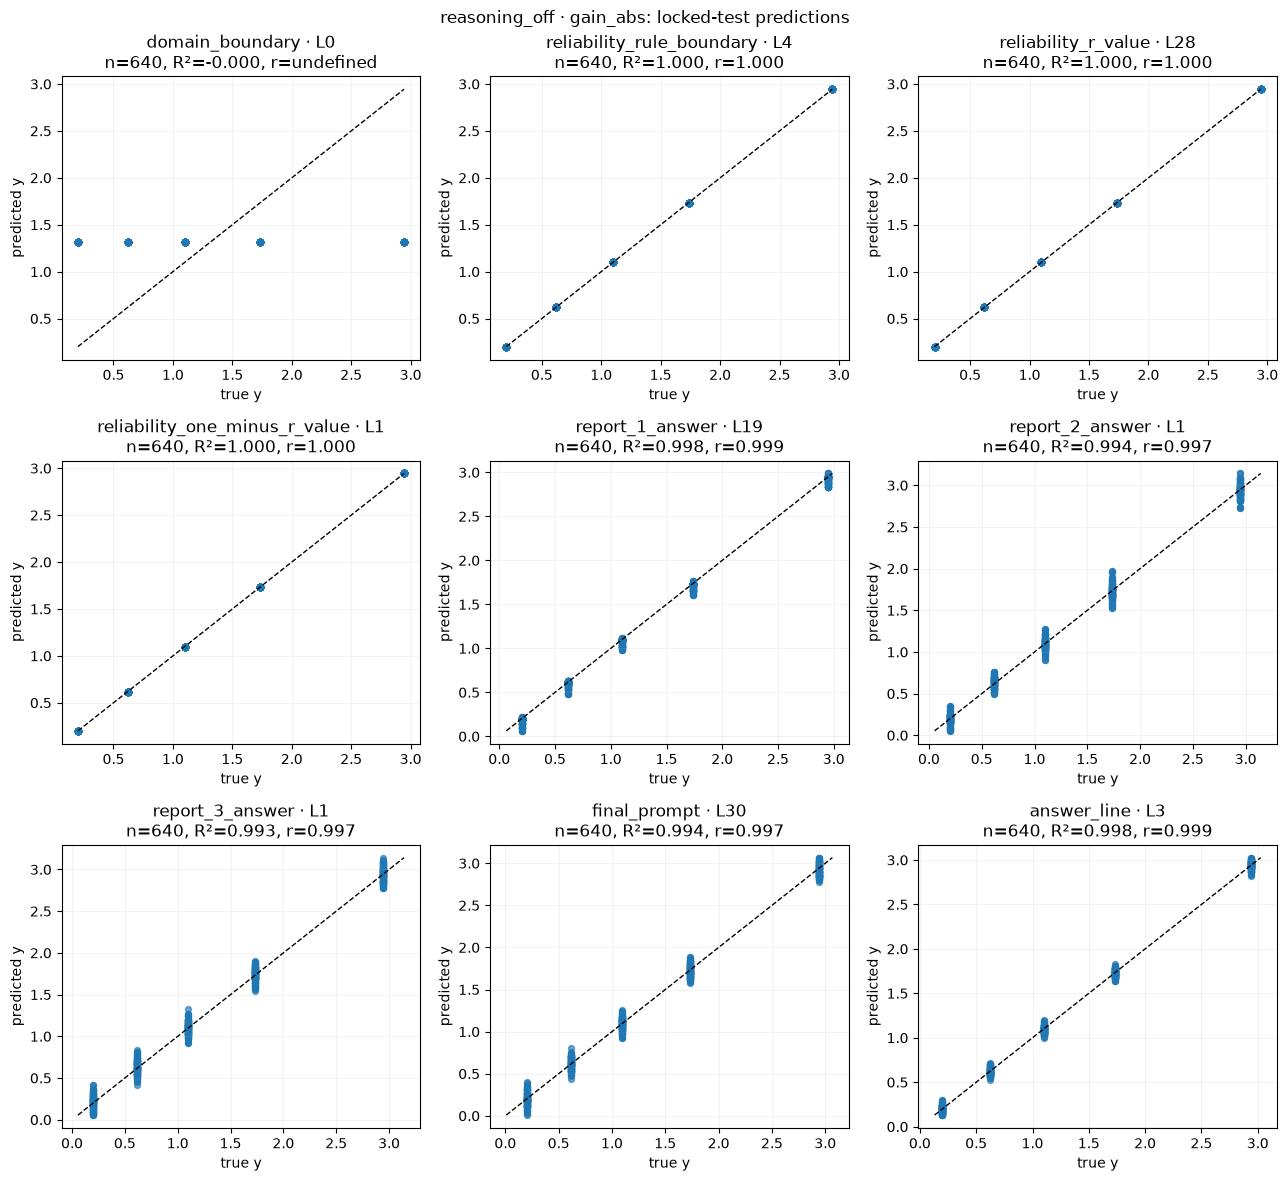

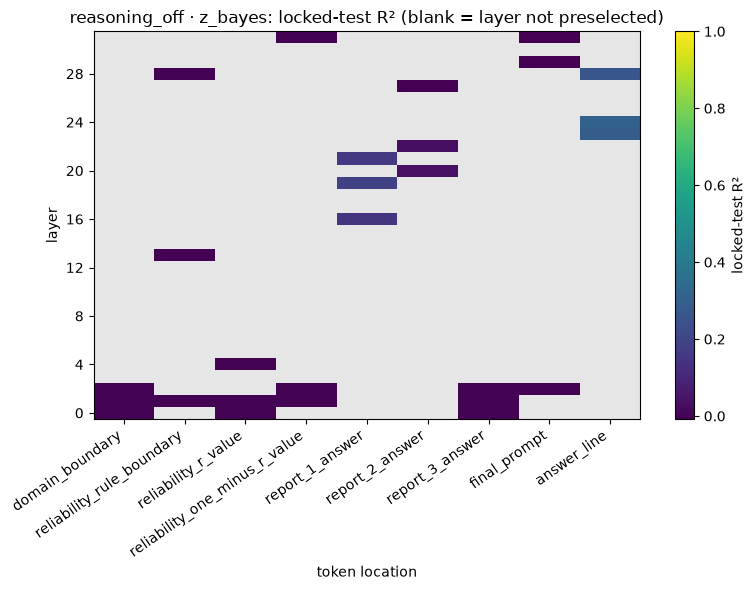

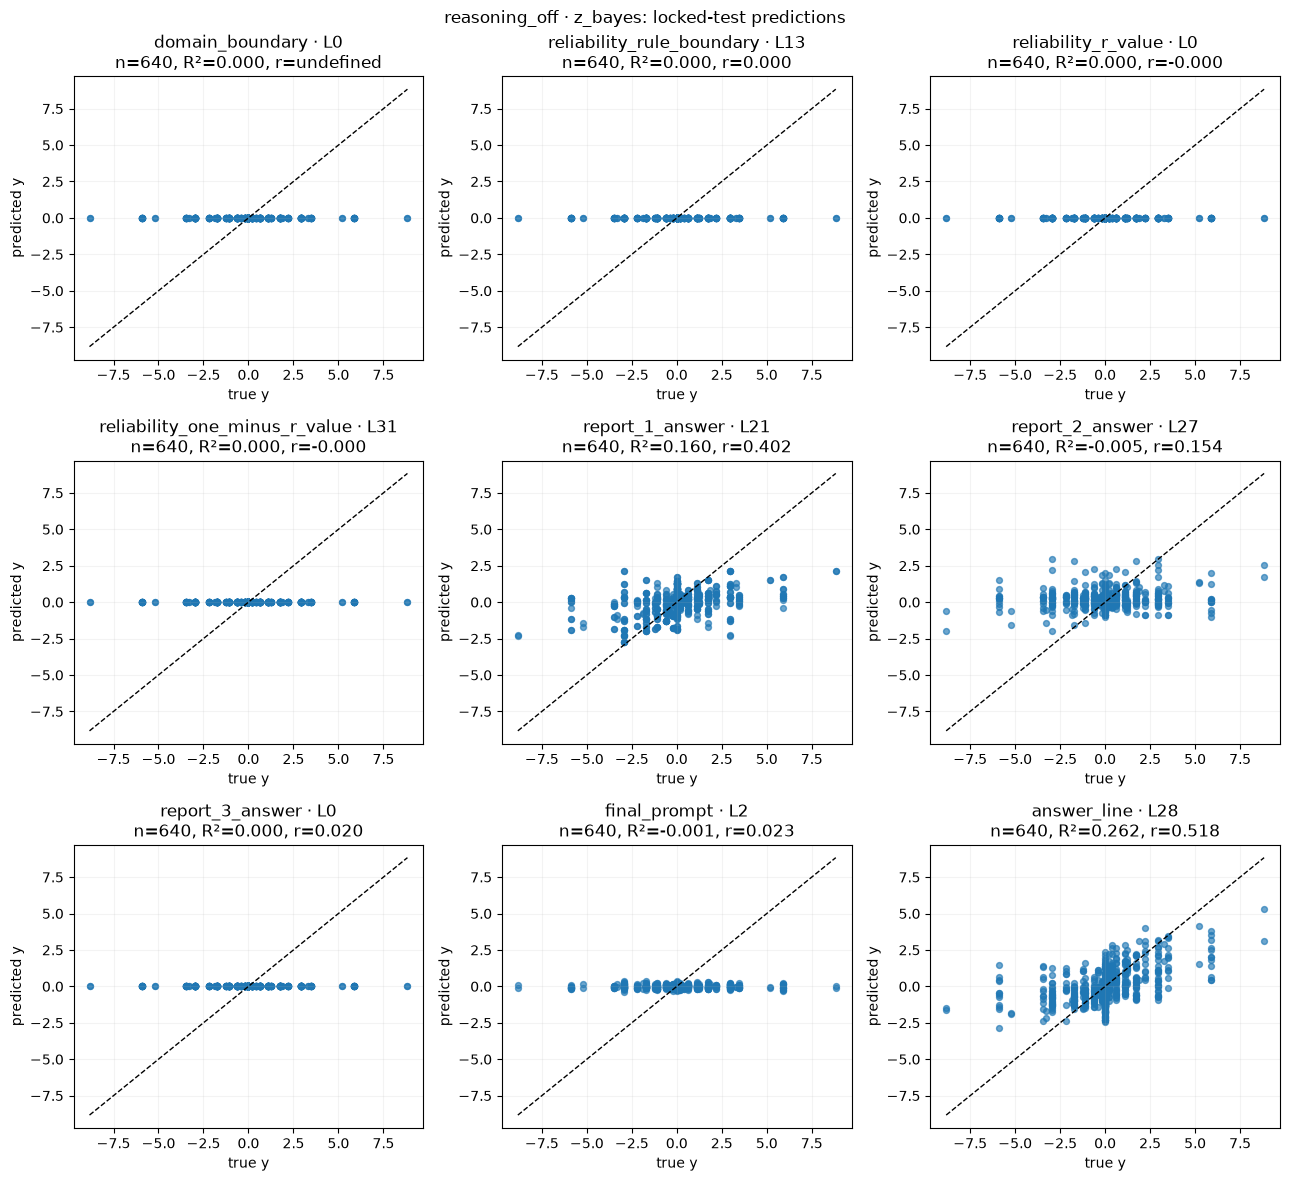

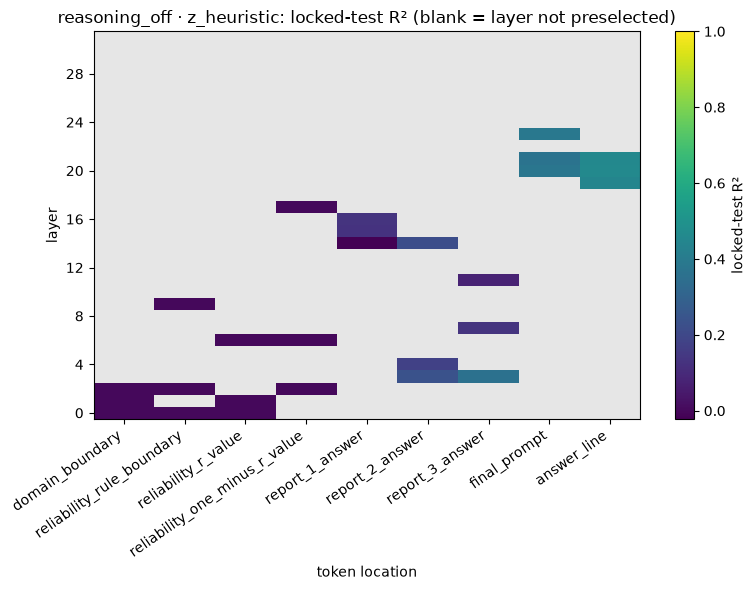

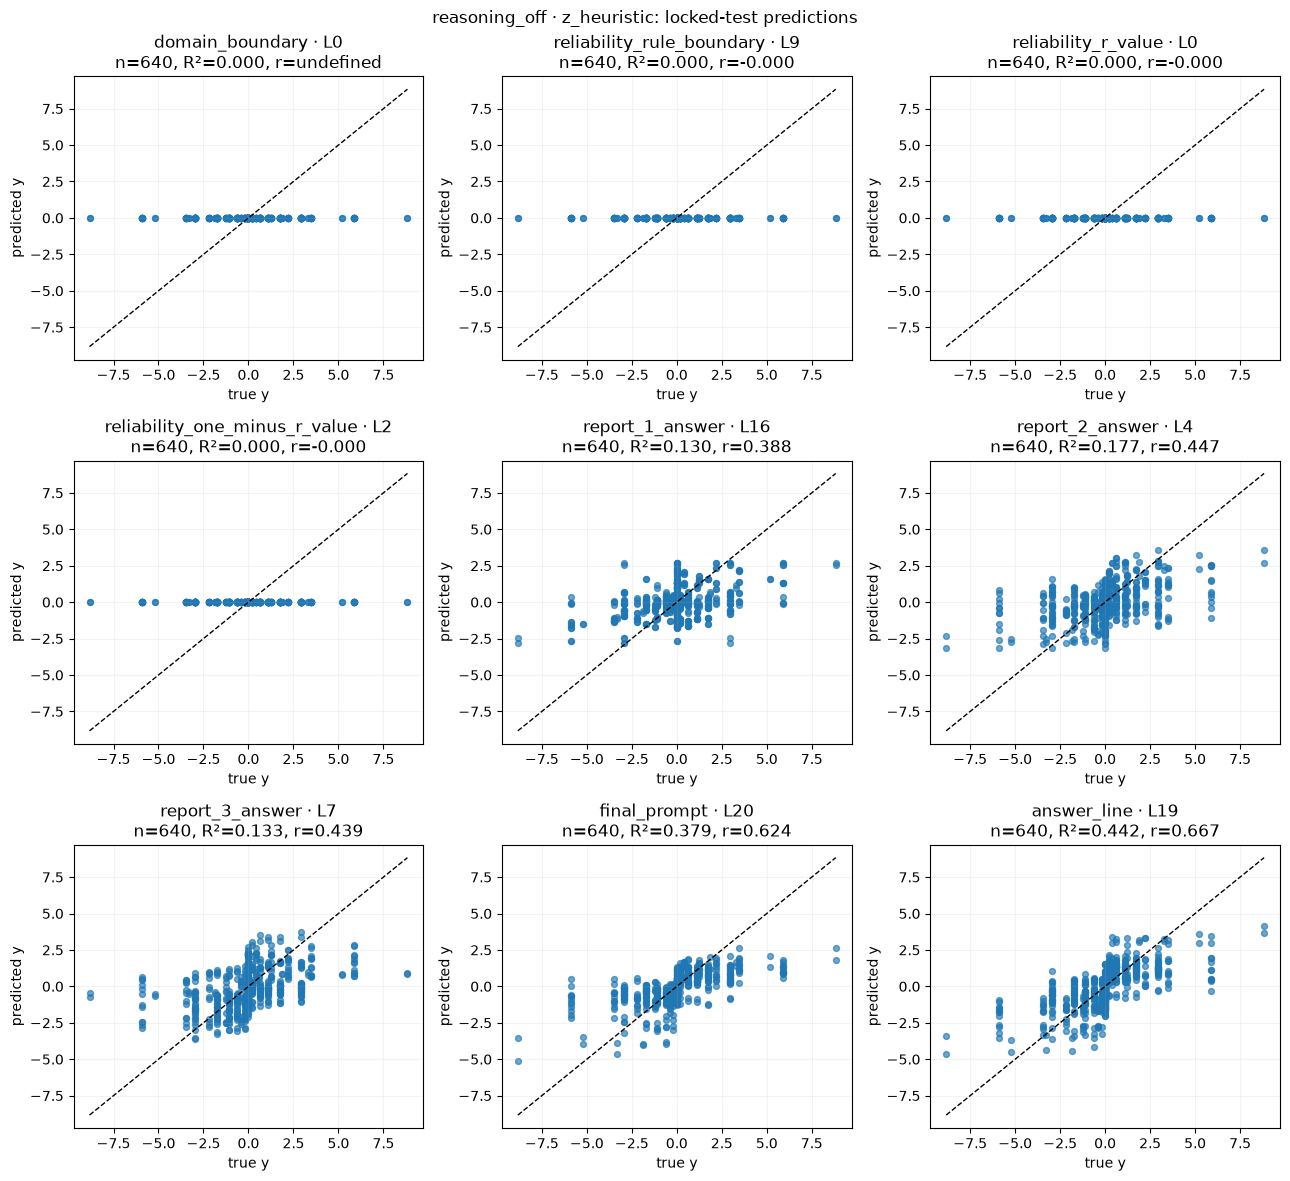

In [15]:
# 1 (locked-test supplement) and 9. These appear only after the test was opened once.
locked_test_metrics_path = PROBE_ROOT / "locked_test_metrics.jsonl"
locked_test_records = read_jsonl_if_present(locked_test_metrics_path)
locked_test_records = [
    row for row in locked_test_records
    if row.get("probe_config_fingerprint") == PROBE_CONFIG_FINGERPRINT and row["subset"] == "all"
]

if RUN_PROBE_VISUALIZATIONS and locked_test_records:
    if results is None or locked_layers is None:
        raise RuntimeError("Loaded captures and locked layers are required for scatterplots.")
    for reasoning in REASONING_VALUES:
        mode_name = MODE_NAMES[reasoning]
        mode_results = results_by_reasoning[reasoning]
        for target in PROBE_PLOT_TARGETS:
            matrix = np.full((len(PROBE_LAYERS), len(PROBE_SITES)), np.nan)
            for row in locked_test_records:
                if (
                    bool(row["reasoning"]) is reasoning
                    and row["target"] == target
                    and row["subset"] == "all"
                ):
                    matrix[
                        int(row["layer"]), PROBE_SITES.index(str(row["site"]))
                    ] = float(row["r2"])
            fig, _ = draw_matrix(
                matrix,
                xlabels=list(PROBE_SITES),
                ylabels=[str(layer) for layer in PROBE_LAYERS],
                title=(
                    f"{mode_name} · {target}: locked-test R² "
                    "(blank = layer not preselected)"
                ),
                colorbar_label="locked-test R²",
                vmin=min(0.0, float(np.nanmin(matrix))),
                vmax=max(1.0, float(np.nanmax(matrix))),
            )
            save_and_display_figure(
                fig, f"01_locked_test_sparse_heatmap_{mode_name}_{target}"
            )

            n_columns = 3
            n_rows = math.ceil(len(PROBE_SITES) / n_columns)
            fig, axes = plt.subplots(
                n_rows, n_columns, figsize=(13, 4.0 * n_rows), squeeze=False
            )
            for site_index, site in enumerate(PROBE_SITES):
                ax = axes.flat[site_index]
                layer = int(locked_layers[mode_name][site][target][0])
                rows = [
                    row for row in rows_available_at_site(mode_results, site)
                    if row["split"] == "test"
                ]
                X_test = activation_matrix(rows, site=site, layer=layer)
                observed = target_array(rows, target)
                predicted = load_probe_prediction(
                    X_test, reasoning=reasoning, site=site,
                    target=target, layer=layer,
                )
                ax.scatter(observed, predicted, s=18, alpha=0.65)
                limits = [
                    min(float(observed.min()), float(predicted.min())),
                    max(float(observed.max()), float(predicted.max())),
                ]
                ax.plot(limits, limits, color="black", ls="--", lw=1)
                metrics = continuous_metrics(observed, predicted)
                pearson_text = (
                    f"{metrics['pearson']:.3f}"
                    if metrics["pearson"] is not None else "undefined"
                )
                ax.set(
                    xlabel="true y", ylabel="predicted y",
                    title=(
                        f"{site} · L{layer}\n"
                        f"n={len(rows)}, R²={metrics['r2']:.3f}, r={pearson_text}"
                    ),
                )
                ax.grid(alpha=0.15)
            for ax in axes.flat[len(PROBE_SITES):]:
                ax.set_visible(False)
            fig.suptitle(f"{mode_name} · {target}: locked-test predictions")
            save_and_display_figure(
                fig, f"09_locked_test_scatter_{mode_name}_{target}"
            )
elif RUN_PROBE_VISUALIZATIONS:
    print("Locked-test heatmaps and scatterplots remain sealed until test evaluation runs.")


### Cross-layer and cross-location transfer

These notebook-16 diagnostics apply fixed probes to held-out activation matrices.
They are exploratory and are not used to revise layer selection. Probe direction
similarity and transfer alone do not demonstrate causal information transport.


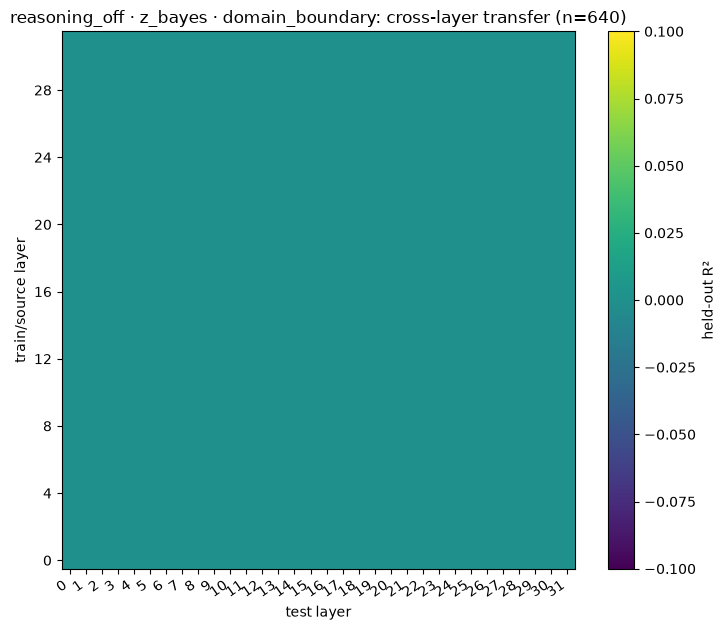

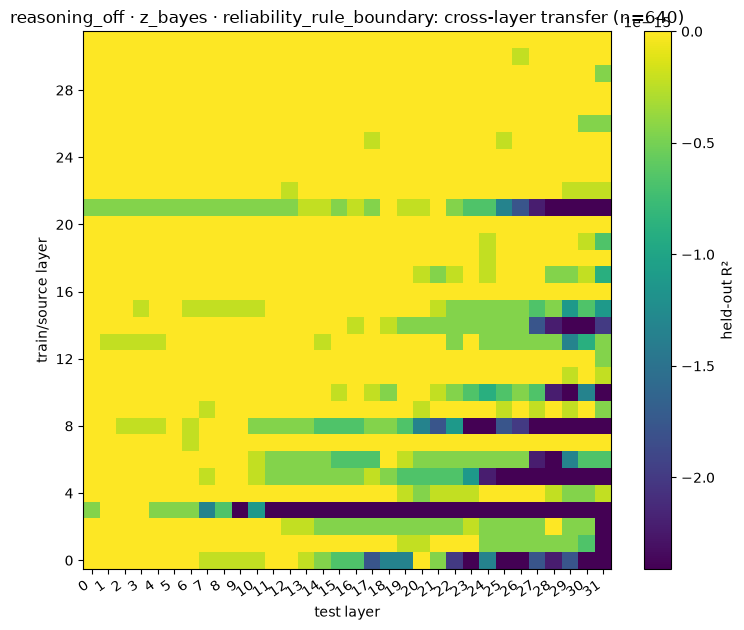

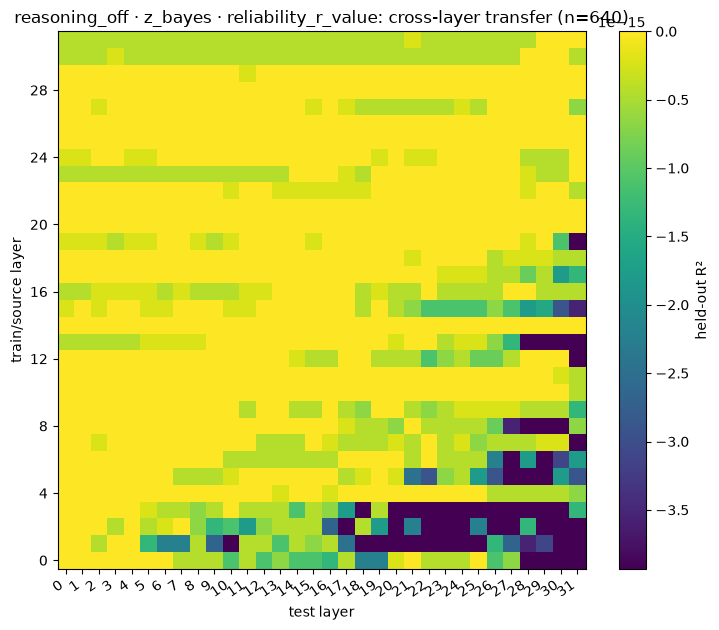

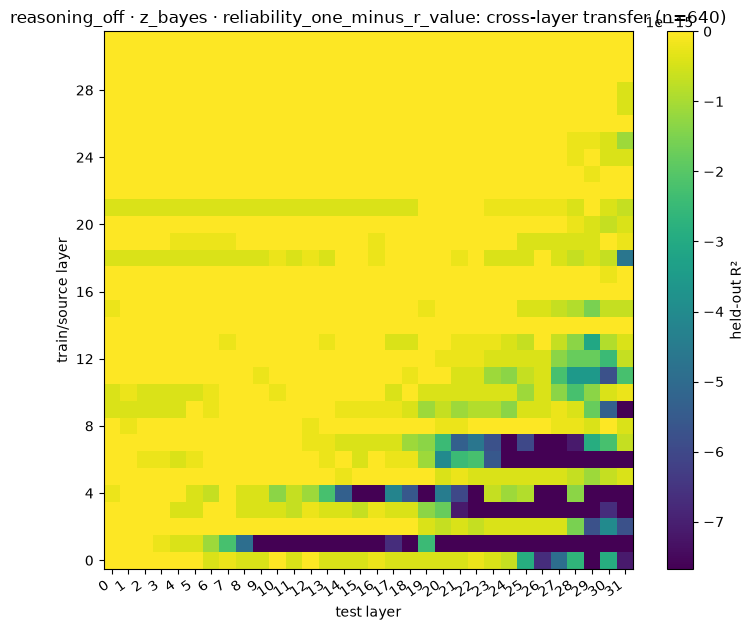

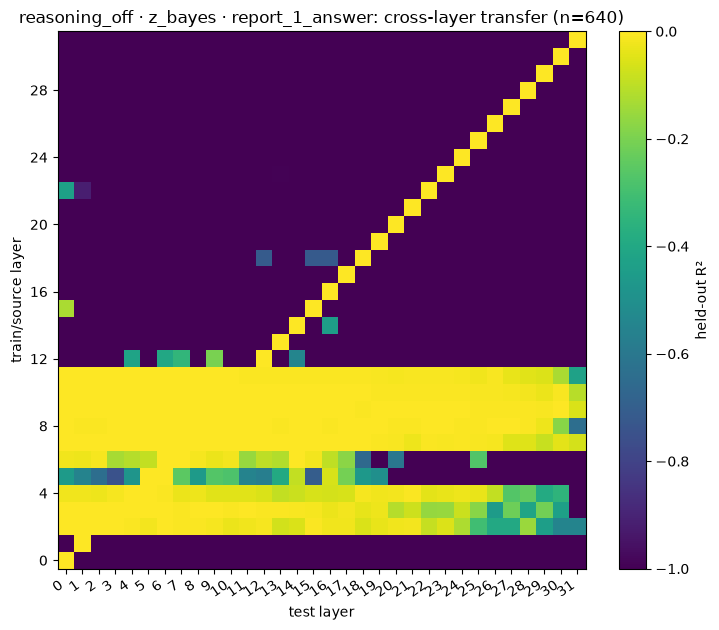

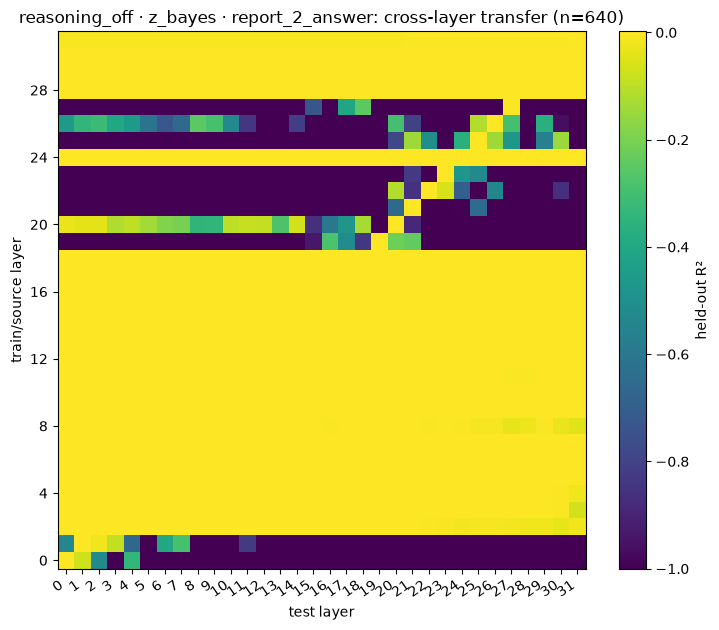

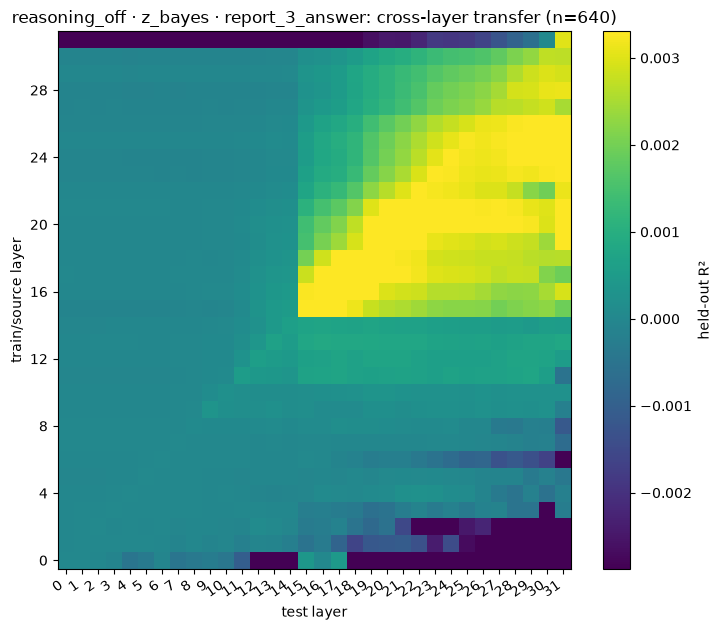

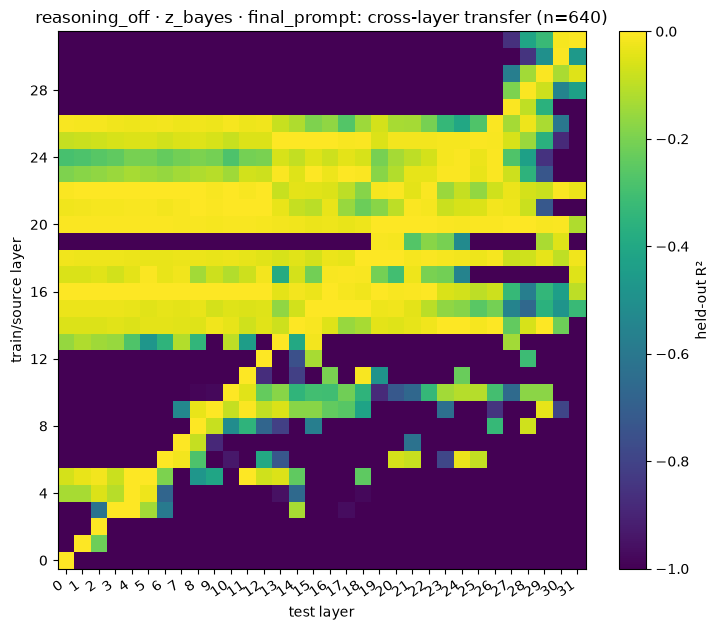

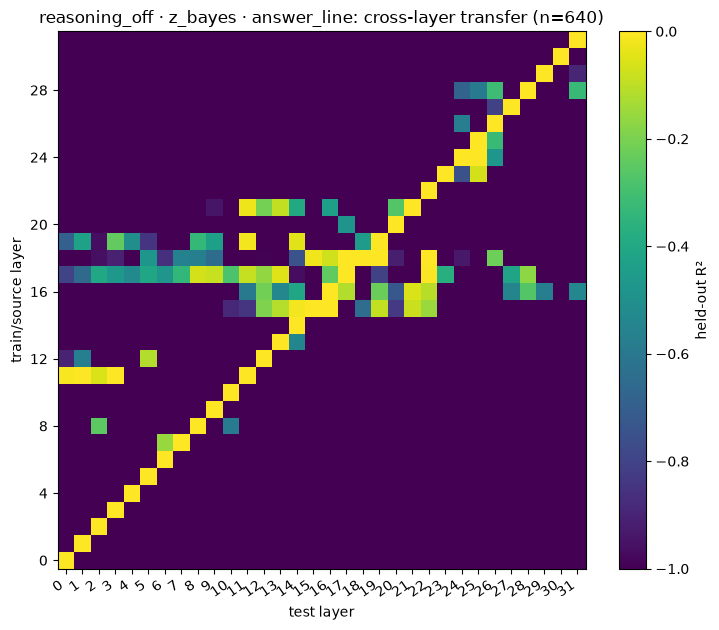

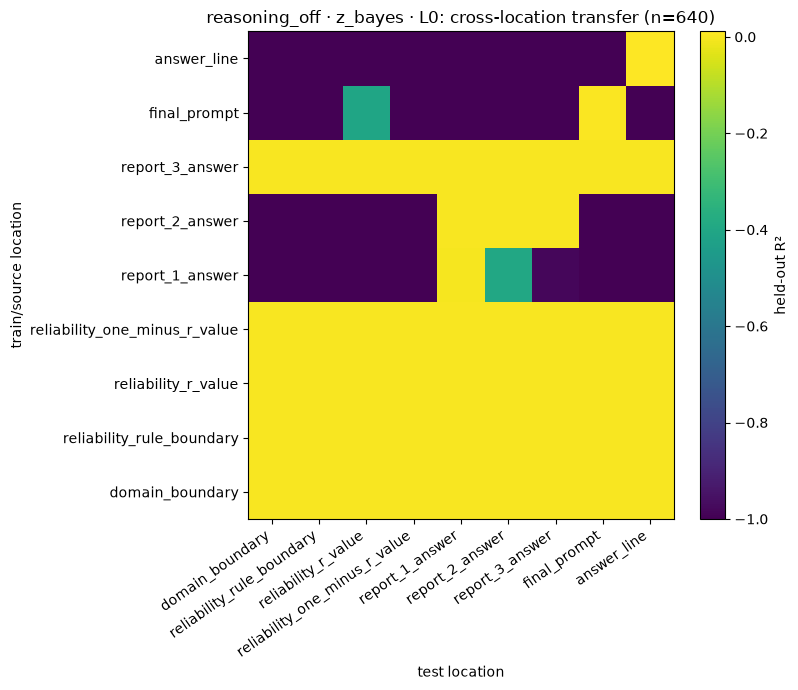

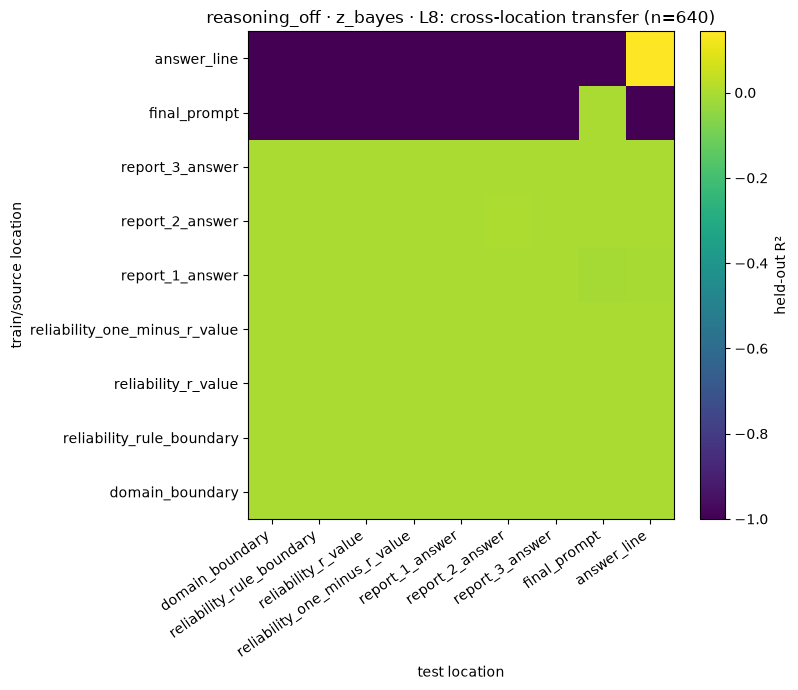

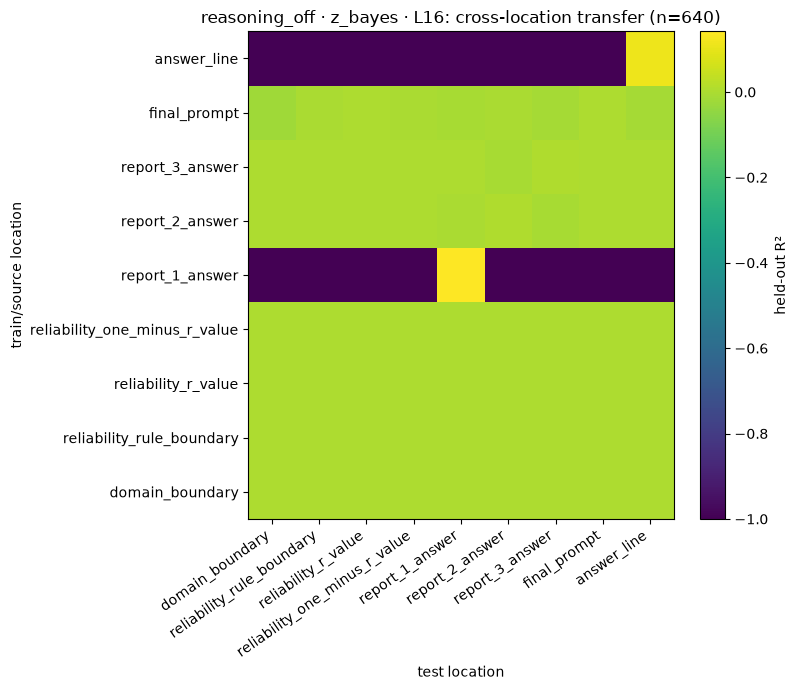

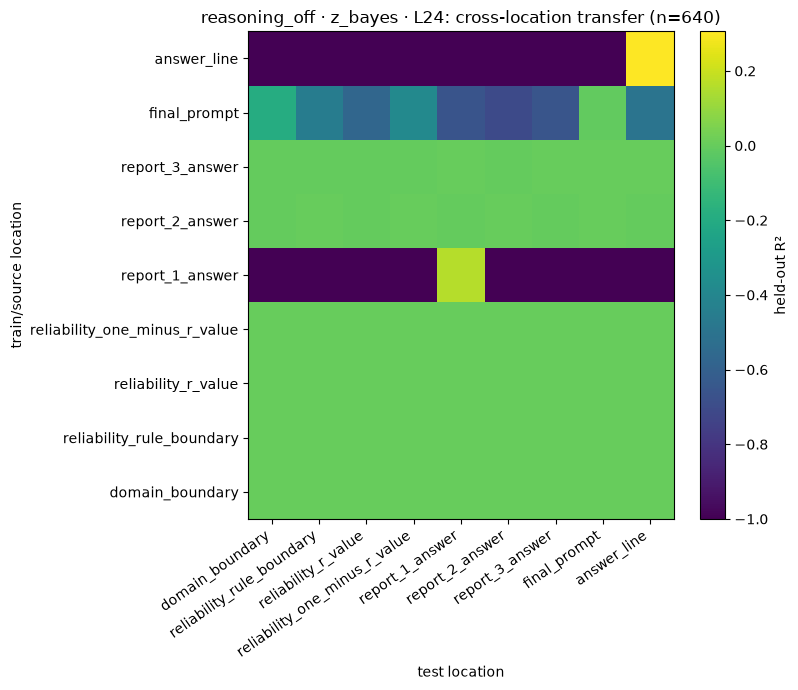

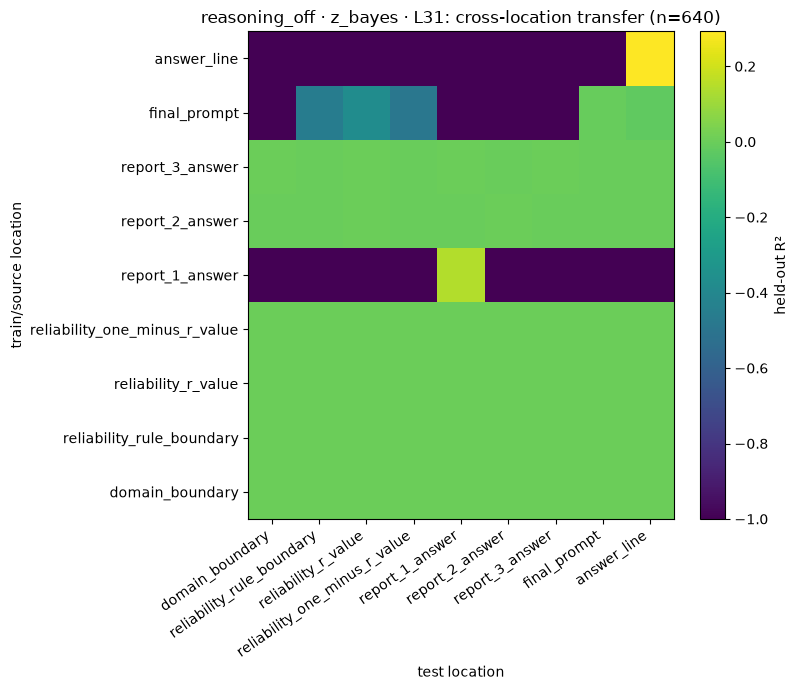

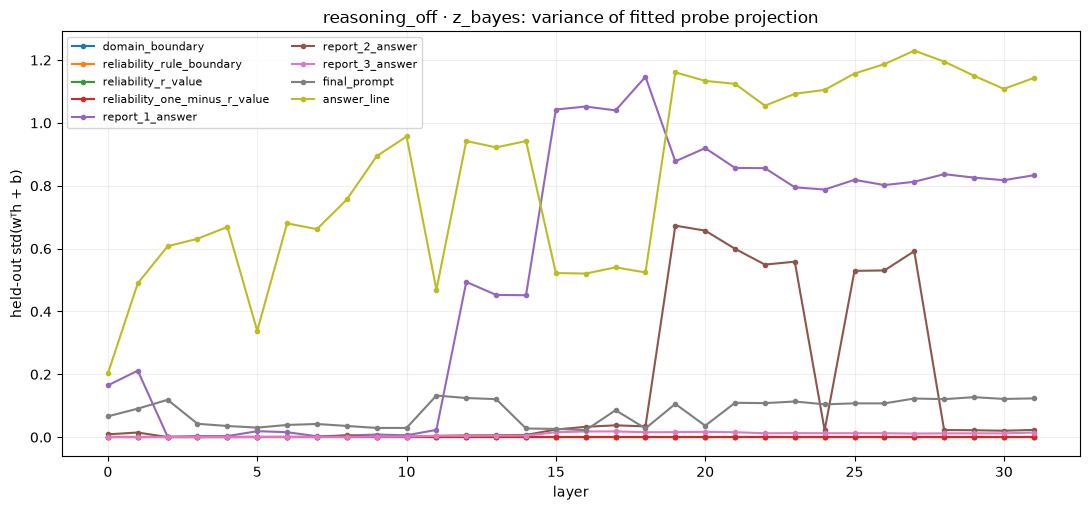

In [16]:
# 5, 6, and the projection-variance companion to 8.
if RUN_PROBE_TRANSFER_ANALYSIS:
    if not locked_test_records:
        raise RuntimeError(
            "Cross-location/layer transfer is gated until locked test evaluation has run."
        )
    if results is None:
        raise RuntimeError("Load the completed activation capture first.")

    projection_rows = []
    for reasoning in REASONING_VALUES:
        mode_name = MODE_NAMES[reasoning]
        mode_results = results_by_reasoning[reasoning]
        for target in PROBE_TRANSFER_TARGETS:
            for site in PROBE_SITES:
                rows = [
                    row for row in rows_available_at_site(mode_results, site)
                    if row["split"] == "test"
                ]
                observed = target_array(rows, target)
                destination_matrices = {
                    int(layer): activation_matrix(
                        rows, site=site, layer=int(layer)
                    )
                    for layer in PROBE_LAYERS
                }
                source_parameters = [
                    probe_affine_parameters(
                        reasoning=reasoning, site=site,
                        target=target, layer=int(layer),
                    )
                    for layer in PROBE_LAYERS
                ]
                directions = np.stack([
                    np.asarray(item["raw_direction"])
                    for item in source_parameters
                ], axis=1)
                intercepts = np.asarray([
                    float(item["raw_intercept"]) for item in source_parameters
                ])
                transfer = np.full(
                    (len(PROBE_LAYERS), len(PROBE_LAYERS)), np.nan
                )
                for destination_index, destination_layer in enumerate(PROBE_LAYERS):
                    predictions = (
                        destination_matrices[int(destination_layer)] @ directions
                        + intercepts
                    )
                    for source_index, _ in enumerate(PROBE_LAYERS):
                        transfer[source_index, destination_index] = r2_score(
                            observed, predictions[:, source_index]
                        )
                    diagonal_prediction = predictions[:, destination_index]
                    projection_rows.append({
                        "reasoning": reasoning,
                        "reasoning_mode": mode_name,
                        "site": site,
                        "target": target,
                        "layer": int(destination_layer),
                        "row_count": len(rows),
                        "projection_variance": float(np.var(diagonal_prediction)),
                        "projection_standard_deviation": float(
                            np.std(diagonal_prediction)
                        ),
                        "probe_config_fingerprint": PROBE_CONFIG_FINGERPRINT,
                    })
                np.savez_compressed(
                    FIGURE_ROOT
                    / (
                        f"cross_layer_{figure_slug(mode_name)}_"
                        f"{figure_slug(target)}_{figure_slug(site)}.npz"
                    ),
                    matrix=transfer,
                    layers=np.asarray(PROBE_LAYERS),
                )
                fig, ax = draw_matrix(
                    transfer,
                    xlabels=[str(layer) for layer in PROBE_LAYERS],
                    ylabels=[str(layer) for layer in PROBE_LAYERS],
                    title=(
                        f"{mode_name} · {target} · {site}: "
                        f"cross-layer transfer (n={len(rows)})"
                    ),
                    colorbar_label="held-out R²",
                    vmin=max(-1.0, float(np.nanpercentile(transfer, 5))),
                    vmax=min(
                        1.0,
                        max(0.0, float(np.nanpercentile(transfer, 95))),
                    ),
                    figsize=(7.4, 6.4),
                )
                ax.set_xlabel("test layer")
                ax.set_ylabel("train/source layer")
                save_and_display_figure(
                    fig, f"05_cross_layer_{mode_name}_{target}_{site}"
                )

            # Cross-location transfer uses the same rows at every destination.
            common_rows = [
                row for row in mode_results
                if row["split"] == "test"
                and all(
                    result_site_position(row, site) is not None
                    for site in PROBE_SITES
                )
            ]
            if not common_rows:
                raise RuntimeError(
                    f"No complete-site test rows for {mode_name}/{target}."
                )
            observed = target_array(common_rows, target)
            for layer in PROBE_TRANSFER_LAYERS:
                destination_matrices = {
                    site: activation_matrix(
                        common_rows, site=site, layer=int(layer)
                    )
                    for site in PROBE_SITES
                }
                transfer = np.full(
                    (len(PROBE_SITES), len(PROBE_SITES)), np.nan
                )
                for source_index, source_site in enumerate(PROBE_SITES):
                    parameters = probe_affine_parameters(
                        reasoning=reasoning, site=source_site,
                        target=target, layer=int(layer),
                    )
                    direction = np.asarray(parameters["raw_direction"])
                    offset = float(parameters["raw_intercept"])
                    for destination_index, destination_site in enumerate(PROBE_SITES):
                        prediction = (
                            destination_matrices[destination_site] @ direction + offset
                        )
                        transfer[source_index, destination_index] = r2_score(
                            observed, prediction
                        )
                np.savez_compressed(
                    FIGURE_ROOT
                    / (
                        f"cross_location_{figure_slug(mode_name)}_"
                        f"{figure_slug(target)}_layer_{int(layer):02d}.npz"
                    ),
                    matrix=transfer,
                    sites=np.asarray(PROBE_SITES),
                    layer=int(layer),
                )
                fig, ax = draw_matrix(
                    transfer,
                    xlabels=list(PROBE_SITES),
                    ylabels=list(PROBE_SITES),
                    title=(
                        f"{mode_name} · {target} · L{int(layer)}: "
                        f"cross-location transfer (n={len(common_rows)})"
                    ),
                    colorbar_label="held-out R²",
                    vmin=max(-1.0, float(np.nanmin(transfer))),
                    vmax=min(1.0, max(0.0, float(np.nanmax(transfer)))),
                    figsize=(8.0, 7.0),
                )
                ax.set_xlabel("test location")
                ax.set_ylabel("train/source location")
                save_and_display_figure(
                    fig,
                    f"06_cross_location_{mode_name}_{target}_layer_{int(layer):02d}",
                )

    atomic_write_jsonl(PROBE_ROOT / "projection_variance.jsonl", projection_rows)
    projection_frame = pd.DataFrame(projection_rows)
    for reasoning in REASONING_VALUES:
        mode_name = MODE_NAMES[reasoning]
        for target in PROBE_TRANSFER_TARGETS:
            fig, ax = plt.subplots(figsize=(11, 5.2))
            selected = projection_frame[
                (projection_frame["reasoning"] == reasoning)
                & (projection_frame["target"] == target)
            ]
            for site in PROBE_SITES:
                site_rows = selected[selected["site"] == site].sort_values("layer")
                ax.plot(
                    site_rows["layer"],
                    site_rows["projection_standard_deviation"],
                    marker="o", ms=3, label=site,
                )
            ax.set(
                xlabel="layer", ylabel="held-out std(wᵀh + b)",
                title=(
                    f"{mode_name} · {target}: variance of fitted probe projection"
                ),
            )
            ax.legend(ncol=2, fontsize=8)
            ax.grid(alpha=0.2)
            save_and_display_figure(
                fig, f"08_projection_std_{mode_name}_{target}"
            )
else:
    print("Transfer matrices are paused: RUN_PROBE_TRANSFER_ANALYSIS=False.")


## Behavior, experiment-2 interpretation, and patch feasibility

Behavior is evaluated separately for saved logits and emitted answers. The matched
exact-question audit and completed original reliability interchange live in notebook
19. The user's clarified agreement-matched clean/incorrect follow-up is in notebook 20.


,split,reliability,non_tie_rows,schedules,emitted_accuracy,boundary_logit_accuracy,emitted_logit_disagreement
0,test,0.05,44,7,0.318182,0.295455,0.068182
1,test,0.15,44,7,0.318182,0.272727,0.113636
2,test,0.25,44,7,0.318182,0.295455,0.022727
3,test,0.35,44,7,0.272727,0.272727,0.045455
4,test,0.45,44,7,0.272727,0.272727,0.022727
5,test,0.55,44,7,0.818182,0.727273,0.113636
6,test,0.65,44,7,0.795455,0.727273,0.113636
7,test,0.75,44,7,0.795455,0.772727,0.068182
8,test,0.85,44,7,0.818182,0.772727,0.068182
9,test,0.95,44,7,0.795455,0.750000,0.068182


,split,reliability,agreement_slope,intercept,bayes_slope
0,test,0.05,0.264323,-0.404297,-2.944439
1,test,0.15,0.260417,-0.337891,-1.734601
2,test,0.25,0.244792,-0.367187,-1.098612
3,test,0.35,0.272135,-0.357422,-0.619039
4,test,0.45,0.292969,-0.359375,-0.200671
5,test,0.55,0.333333,-0.257812,0.200671
6,test,0.65,0.341146,-0.251953,0.619039
7,test,0.75,0.352865,-0.189453,1.098612
8,test,0.85,0.377604,-0.197266,1.734601
9,test,0.95,0.399740,-0.166016,2.944439


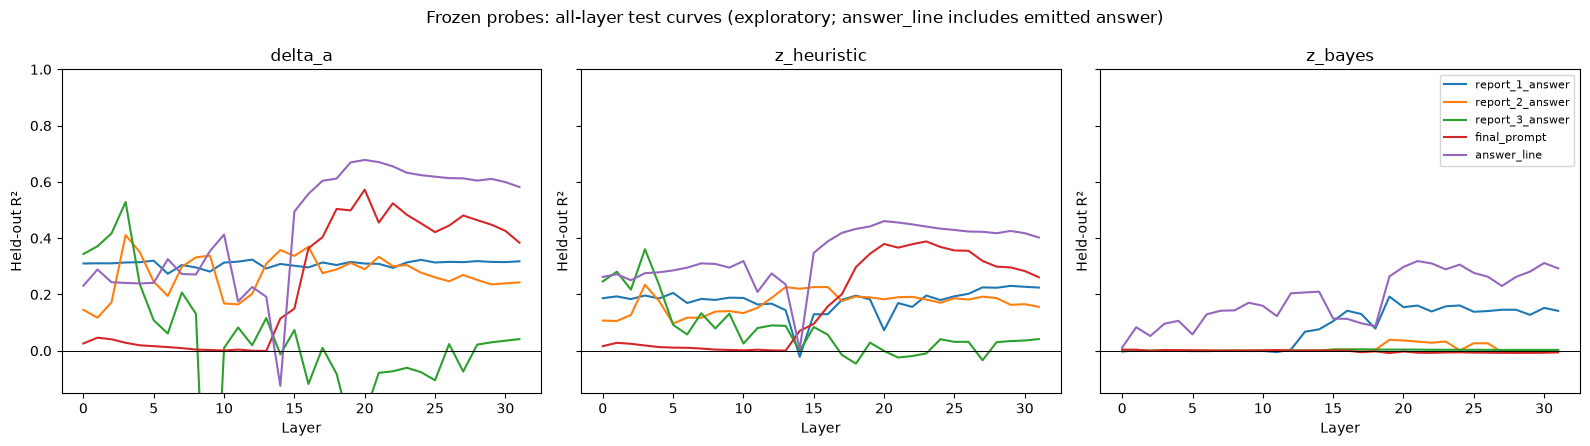

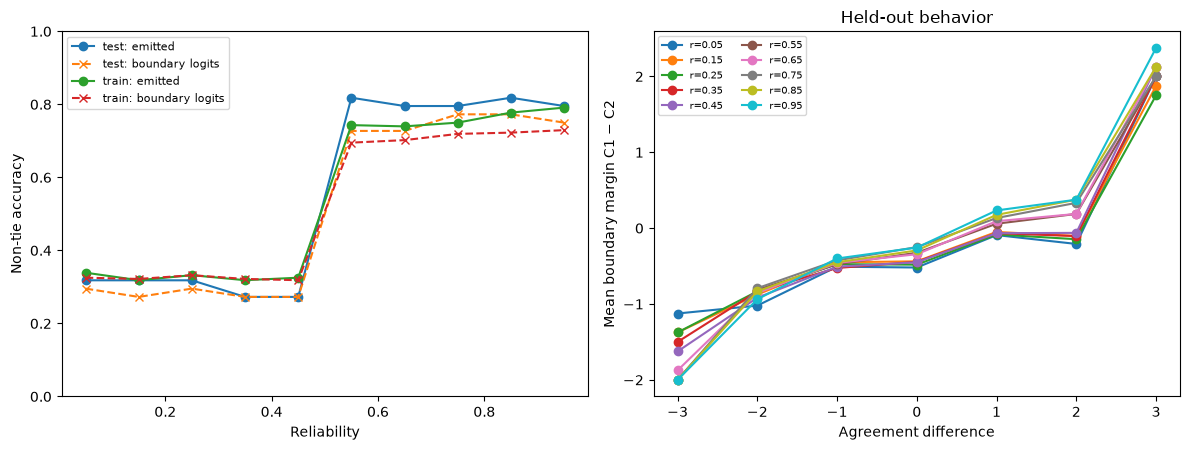

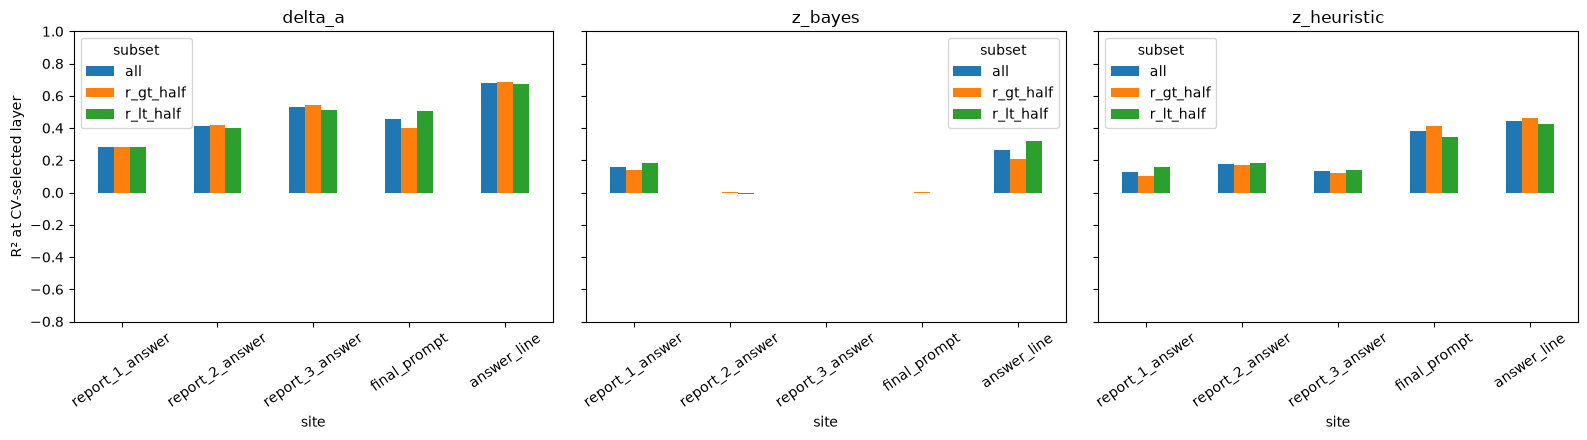

{'matching_fields': ['reliabilities_exact',
  'membership_sets',
  'observed_reports',
  'presentation_order',
  'candidate_1',
  'candidate_2',
  'reasoning'],
 'low_reliability_non_tie_rows': 1680,
 'unique_exact_conditions': 1680,
 'repeated_exact_conditions': 0,
 'exact_clean_corrupt_groups': 0,
 'exact_directed_clean_to_corrupt_pairs': 0,
 'high_reliability_c2_audit_count': 335,
 'low_reliability_c1_audit_count': 41,
 'low_c1_emitted_correct_but_nonpositive_margin': 7,
 'conclusion': 'No exact matched clean/incorrect donors exist in this one-output-per-prompt bank. Same reliability, questions, reports, candidates and ordering fix the prompt. Repeated stochastic generations would not change pre-answer deterministic states in evaluation mode.'}

# Notebook 18: completed reasoning-off probe findings

Frozen at 2026-09-05T02:09:29.780481+00:00: 9 complete sites,
1728 existing probes. Training used 56 schedules / 4,480 rows;
test uses eight held-out schedules / 640 rows. Layer indices are zero-based.

| site | target | layer | best_cv_score | r2 | auroc |
| --- | --- | --- | --- | --- | --- |
| report_3_answer | z_bayes | 0 | -0.0000 | 0.0000 | — |
| report_3_answer | gain_abs | 1 | 0.9921 | 0.9930 | — |
| report_3_answer | delta_a | 3 | 0.3591 | 0.5286 | — |
| report_3_answer | z_heuristic | 7 | 0.2252 | 0.1333 | — |
| report_3_answer | reliability_sign | 28 | 1.0000 | — | 1.0000 |
| report_3_answer | gain | 31 | 0.9794 | 0.9796 | — |
| final_prompt | z_bayes | 2 | 0.0024 | -0.0009 | — |
| final_prompt | reliability_sign | 2 | 1.0000 | — | 1.0000 |
| final_prompt | z_heuristic | 20 | 0.2370 | 0.3793 | — |
| final_prompt | delta_a | 21 | 0.3773 | 0.4553 | — |
| final_prompt | gain | 30 | 0.9964 | 0.9974 | — |
| final_prompt | gain_abs | 30 | 0.9948 | 0.9944 | — |
| answer_line | reliability_sign | 2 | 1.0000 | — | 1.0000 |
| answer_line | gain_abs | 3 | 0.9977 | 0.9983 | — |
| answer_line | gain | 12 | 0.9942 | 0.9930 | — |
| answer_line | z_heuristic | 19 | 0.3757 | 0.4417 | — |
| answer_line | delta_a | 20 | 0.5347 | 0.6780 | — |
| answer_line | z_bayes | 28 | 0.1887 | 0.2625 | — |


Reliability and its sign are readily decoded. Agreement and the unsigned heuristic
are better represented than the signed Bayesian interaction near the prompt boundary.
This is consistent with experiment 2's H1: separately available ingredients are not
successfully composed into the signed product used for a direct answer. It is not
proof that the product is absent: a nonlinear or distributed code can evade a linear
probe. Nor does decoding alone show the model causally uses a variable.

The generated answer-line site includes the answer numeral itself. Its stronger
decodability cannot establish that a Bayesian state existed before the answer.
The bank holds out schedules, but not reliability values, prompt renderings or
candidate identities; all rows use candidates 2/7 in one order. It therefore does
not meet experiment 2's complete crossed generalization design. No causal rescue
claim follows from these probes.

The original report's below-chance failure can be tested against the saved behavior
plots: a positive slope of C1−C2 margin on agreement at r<0.5 has the wrong Bayesian
sign. The exact slope is log(r/(1−r)), which is negative in that regime. CSVs retain
separate emitted-answer and teacher-forced boundary-logit accuracy, excluding exact
Bayesian ties from both choice metrics.

The two user selections reproduce counts 335
and 41. Among the latter,
7 have nonpositive saved
C1−C2 margins despite emitting C1. These must not be silently labeled logit-clean.

Exact follow-up match: 0 donor/recipient
pairs satisfy all requested matching fields. This dataset contains one result per
exact prompt. A change in question sets, reports, reliability, prompt or ordering
would be a different matching design and must be stated explicitly. Notebook 19
preserves this constraint and records the audit; an empty design is not evidence
that patching cannot work.

All-layer test curves and transfer plots are exploratory. The top-three layer lock
was saved before reading test activations and remains unchanged. Reliability-site
agreement probes are negative controls: those sites occur before the evidence.
See `reports/research_agenda/NOTEBOOK13_UPDATE.md`, experiment 2, for the intended
causal interchange and control requirements.


In [17]:
behavior, slopes = behavior_audit(results, ANALYSIS_ROOT)
display(behavior)
display(slopes)
plot_diagnostics(results, all_test_metrics, prediction_frame, snapshot, ANALYSIS_ROOT)
pair_audit = match_audit(results, ANALYSIS_ROOT)
display(pair_audit)
interpretation = write_interpretation(results, test_metric_rows, all_test_metrics,
                                    behavior, slopes, pair_audit, snapshot, ANALYSIS_ROOT)
display(Markdown(interpretation))


In [18]:
final_status = {
    'reasoning_off_only': all(row['reasoning'] is False for row in results),
    'complete_sites': list(PROBE_SITES),
    'frozen_probe_count': len(probe_cv_records),
    'test_metric_count': len(all_test_metrics),
    'original_training_untouched': True,
    'cuda_available': torch.cuda.is_available(),
    'analysis_root': str(ANALYSIS_ROOT),
}
atomic_write_json(ANALYSIS_ROOT / 'notebook_status.json', final_status)
display(final_status)


{'reasoning_off_only': True,
 'complete_sites': ['domain_boundary',
  'reliability_rule_boundary',
  'reliability_r_value',
  'reliability_one_minus_r_value',
  'report_1_answer',
  'report_2_answer',
  'report_3_answer',
  'final_prompt',
  'answer_line'],
 'frozen_probe_count': 1728,
 'test_metric_count': 5184,
 'original_training_untouched': True,
 'cuda_available': False,
 'analysis_root': '/workspace/MATS/artifacts/noisy_channel_bayesian_experiment_2_activation_patching/Qwen_Qwen3.5-9B_4c87a623/analyses/completed_reasoning_off_20260905'}

## Newly completed site: assistant turn boundary

Training finished this additional 32-layer sweep while the original nine-site
analysis and reliability-interchange experiment were running. It is frozen in a
separate supplement, using training CV to lock layers before reading its test
activations. The original snapshot and patch-layer selections remain unchanged.
All calculations in this supplement use CPU and reasoning-off rows only.


CPU test cache: 80/640 files, 1 sites × 32 layers


CPU test cache: 160/640 files, 1 sites × 32 layers


CPU test cache: 240/640 files, 1 sites × 32 layers


CPU test cache: 320/640 files, 1 sites × 32 layers


CPU test cache: 400/640 files, 1 sites × 32 layers


CPU test cache: 480/640 files, 1 sites × 32 layers


CPU test cache: 560/640 files, 1 sites × 32 layers


CPU test cache: 640/640 files, 1 sites × 32 layers


Evaluated frozen probes on test: assistant_turn_boundary


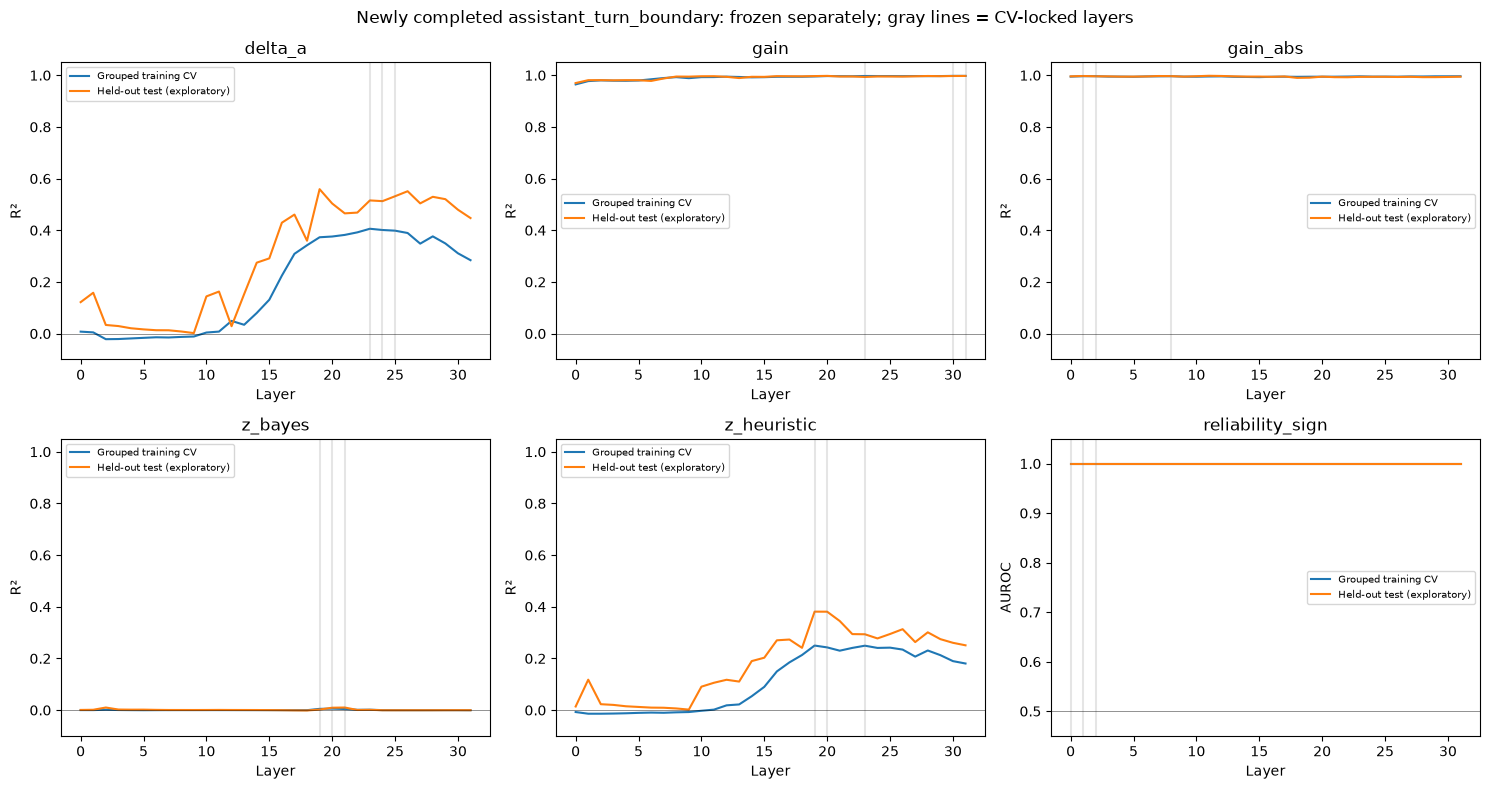

,site,target,layer,best_cv_score,r2,auroc,row_count
0,assistant_turn_boundary,reliability_sign,0,1.000000,NaN,1.0,640
3,assistant_turn_boundary,gain_abs,1,0.996383,0.997115,NaN,640
21,assistant_turn_boundary,z_heuristic,19,0.249843,0.381119,NaN,640
24,assistant_turn_boundary,z_bayes,20,0.005817,0.009249,NaN,640
33,assistant_turn_boundary,delta_a,23,0.405841,0.515510,NaN,640
48,assistant_turn_boundary,gain,30,0.997545,0.997118,NaN,640


In [5]:
from completed_probe_exploration import completed_site_supplement
supplement_summary = completed_site_supplement(
    SOURCE_PROBE_ROOT, ANALYSIS_ROOT, REPO_ROOT, results, RUN_DIRS[False],
    'assistant_turn_boundary')
display(supplement_summary)


## Newly completed site: candidate question boundary

This additional site completed its six 32-layer sweeps while the agreement-matched
patch experiment was running. Its weights and training-CV layer choices are frozen
in another separate supplement before reading its test activations. Neither the
original probe snapshot nor the running patch protocol or selection rule changes.


CPU test cache: 80/640 files, 1 sites × 32 layers


CPU test cache: 160/640 files, 1 sites × 32 layers


CPU test cache: 240/640 files, 1 sites × 32 layers


CPU test cache: 320/640 files, 1 sites × 32 layers


CPU test cache: 400/640 files, 1 sites × 32 layers


CPU test cache: 480/640 files, 1 sites × 32 layers


CPU test cache: 560/640 files, 1 sites × 32 layers


CPU test cache: 640/640 files, 1 sites × 32 layers


Evaluated frozen probes on test: candidate_question_boundary


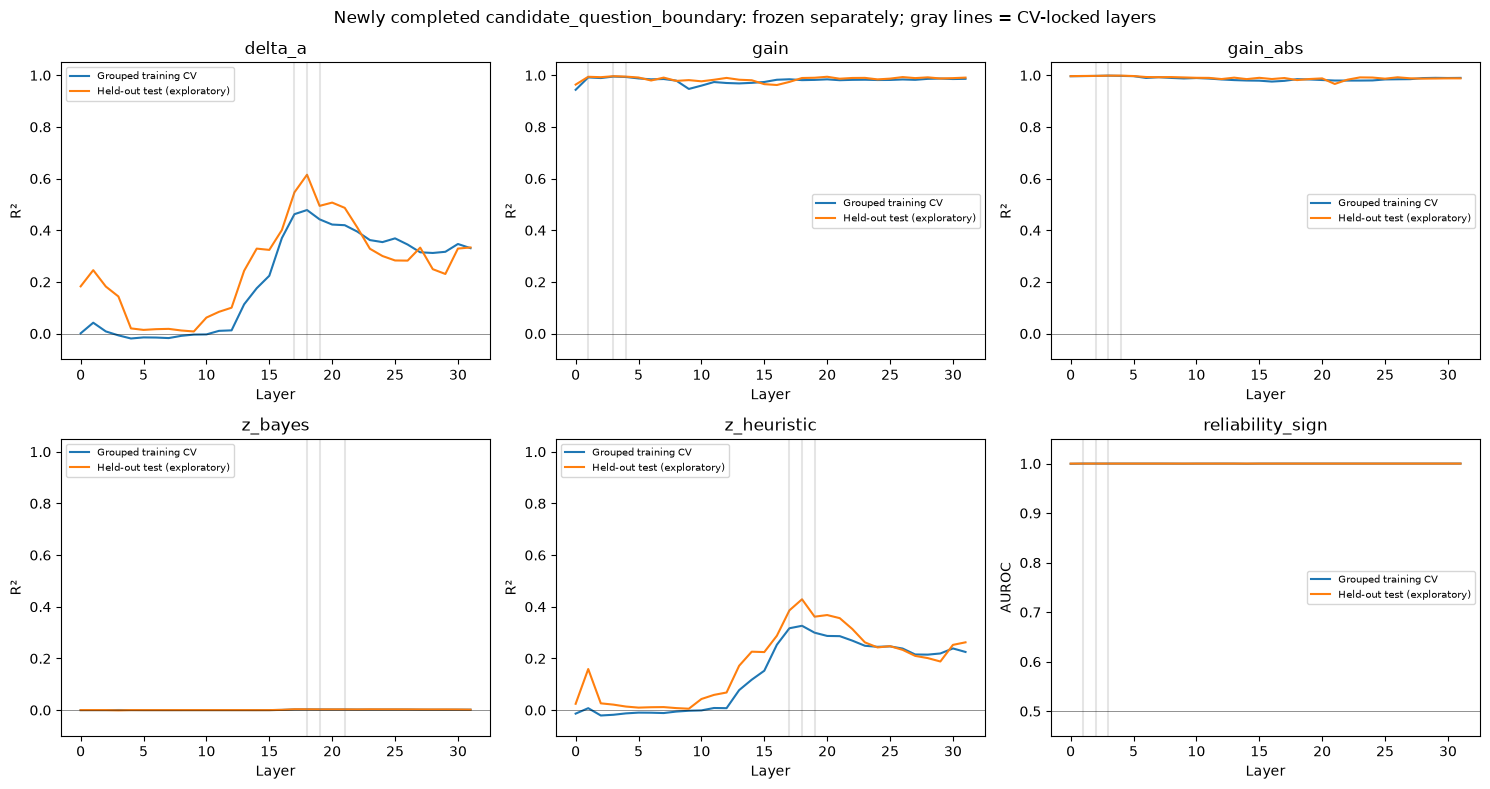

,site,target,layer,best_cv_score,r2,auroc,row_count
3,candidate_question_boundary,reliability_sign,1,1.000000,NaN,1.0,640
12,candidate_question_boundary,gain,3,0.994971,0.996376,NaN,640
15,candidate_question_boundary,gain_abs,3,0.998481,0.998525,NaN,640
33,candidate_question_boundary,delta_a,18,0.478325,0.615002,NaN,640
36,candidate_question_boundary,z_bayes,18,0.002650,0.003119,NaN,640
39,candidate_question_boundary,z_heuristic,18,0.326344,0.428943,NaN,640


In [6]:
from completed_probe_exploration import completed_site_supplement
candidate_boundary_summary = completed_site_supplement(
    SOURCE_PROBE_ROOT, ANALYSIS_ROOT, REPO_ROOT, results, RUN_DIRS[False],
    'candidate_question_boundary')
display(candidate_boundary_summary)
